# Supplementary Sequence Clustering and Analysis

This supplementary analysis constructs sequence clusters from monthly activity histories between September 2006 and April 2009.

Its purpose is to examine whether participants with the same age-18 activity outcome had different longitudinal activity patterns before the May 2009 endpoint. The May 2009 endpoint is excluded from the 32-month histories used for clustering. The cluster solution is selected from the sequence data and only then compared descriptively with the primary four-category outcome.

# Part 1: Source and Sample Definition

In [1]:
# 1: Set project paths and import packages

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

working_directory = Path.cwd().resolve()

# Locate the project root from either the root directory or a notebook subdirectory.
project_root = next(
    (
        directory
        for directory in (
            working_directory,
            *working_directory.parents,
        )
        if (
            directory
            / "data_derived"
            / "stage_1_outcome_construction"
        ).exists()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "The Stage 1 outcome directory could not be located."
    )

stage_1_output_directory = (
    project_root
    / "data_derived"
    / "stage_1_outcome_construction"
)

source_review_path = stage_1_output_directory / "stage_1_source_review.csv"
age18_outcome_path = stage_1_output_directory / "age18_activity_outcome.csv"
outcome_distribution_path = (
    stage_1_output_directory / "age18_activity_outcome_distribution.csv"
)
outcome_codebook_path = (
    stage_1_output_directory / "age18_activity_outcome_codebook.csv"
)

required_stage_1_files = [
    source_review_path,
    age18_outcome_path,
    outcome_distribution_path,
    outcome_codebook_path,
]

missing_stage_1_files = [
    path for path in required_stage_1_files if not path.exists()
]

if missing_stage_1_files:
    raise FileNotFoundError(
        "Missing Stage 1 file(s): "
        + ", ".join(path.name for path in missing_stage_1_files)
    )

print("Project root located.")
print(
    "Stage 1 output directory:",
    stage_1_output_directory.relative_to(project_root),
)


Project root located.
Stage 1 output directory: data_derived\stage_1_outcome_construction


In [2]:
# 2: Read the Stage 1 source review and primary outcome

source_review = pd.read_csv(source_review_path)
age18_outcome = pd.read_csv(age18_outcome_path, dtype={'NSID': 'string', 'age18_outcome_code': 'int64', 'age18_outcome': 'string'})
outcome_distribution = pd.read_csv(outcome_distribution_path)
outcome_codebook = pd.read_csv(outcome_codebook_path, dtype={'included_in_outcome': 'boolean'})
endpoint_candidates = source_review.loc[source_review['variable_label'].str.contains('may 2009', case=False, na=False) & source_review['variable_label'].str.contains('main activity at 18', case=False, na=False)].copy()
if len(endpoint_candidates) != 1:
    raise ValueError('The Stage 1 source review did not identify one May 2009 main-activity endpoint.')
selected_endpoint = endpoint_candidates.iloc[0]
monthly_activity_path = project_root / selected_endpoint['source_path']
endpoint_variable = selected_endpoint['variable']
endpoint_variable_label = selected_endpoint['variable_label']
if not monthly_activity_path.exists():
    raise FileNotFoundError(f'Monthly activity source not found: {monthly_activity_path}')
endpoint_order = outcome_distribution['age18_outcome'].astype('string').tolist()
print('Selected source file:')
print(f'- {monthly_activity_path.name}')
print()
print('Selected endpoint variable:')
print(f'- {endpoint_variable}: {endpoint_variable_label}')
print()
print('Primary outcome participants:', len(age18_outcome))
display(outcome_distribution)

Selected source file:
- lsype_main_activity_w4-7_nov2011_suppressed.dta

Selected endpoint variable:
- W7FinAct53_B11: DV: Main Activity May 2009 - Bulletin 11 (Main Activity at 18)

Primary outcome participants: 9767


,age18_outcome,count,percentage
0,Education,5132,52.544282
1,Employment,2831,28.985359
2,Apprenticeship or training,524,5.365005
3,Unemployment or inactivity (NEET),1280,13.105355


In [3]:
# 3: Inspect the monthly activity source

# Use regular expressions to identify variable-name patterns
import re
monthly_activity = pd.read_stata(monthly_activity_path, convert_categoricals=False)
monthly_activity['NSID'] = monthly_activity['NSID'].astype('string')
with pd.io.stata.StataReader(monthly_activity_path) as reader:
    variable_labels = reader.variable_labels()
monthly_activity_candidates = []
for variable, label in variable_labels.items():
    if 'main activity' not in str(label).lower():
        continue
    match = re.fullmatch('W7FinAct(\\d+)_B11', variable)
    if match:
        monthly_activity_candidates.append({'variable_number': int(match.group(1)), 'variable': variable, 'variable_label': str(label)})
monthly_activity_candidates = pd.DataFrame(monthly_activity_candidates).sort_values('variable_number').reset_index(drop=True)
print('Monthly activity source')
print('-----------------------')
print('Rows:', len(monthly_activity))
print('Columns:', monthly_activity.shape[1])
print('Unique NSID:', monthly_activity['NSID'].nunique(dropna=True))
print('Duplicate NSID:', monthly_activity['NSID'].duplicated().sum())
print('Missing NSID:', monthly_activity['NSID'].isna().sum())
print()
print('Monthly main-activity variables:', len(monthly_activity_candidates))
print(
    'Variable range:',
    monthly_activity_candidates.iloc[0]['variable'],
    'to',
    monthly_activity_candidates.iloc[-1]['variable'],
)

Monthly activity source
-----------------------
Rows: 11811
Columns: 46
Unique NSID: 11811
Duplicate NSID: 0
Missing NSID: 0

Monthly main-activity variables: 45
Variable range: W7FinAct21_B11 to W7FinAct65_B11


In [4]:
# 4: Select the 32-month pre-endpoint history

start_reference = 'september 2006'
history_end_reference = 'april 2009'
start_rows = monthly_activity_candidates.loc[monthly_activity_candidates['variable_label'].str.contains(start_reference, case=False, na=False)]
history_end_rows = monthly_activity_candidates.loc[monthly_activity_candidates['variable_label'].str.contains(history_end_reference, case=False, na=False)]
if len(start_rows) != 1 or len(history_end_rows) != 1:
    raise ValueError('The pre-endpoint activity period could not be identified from the variable labels.')
start_number = int(start_rows.iloc[0]['variable_number'])
history_end_number = int(history_end_rows.iloc[0]['variable_number'])
selected_history = monthly_activity_candidates.loc[monthly_activity_candidates['variable_number'].between(start_number, history_end_number)].copy()
history_columns = selected_history['variable'].tolist()

# Keep the May 2009 endpoint outside the sequence so it cannot influence cluster construction.
endpoint_column = endpoint_variable
if len(history_columns) != 32:
    raise ValueError('The pre-endpoint period did not contain 32 months.')
if endpoint_column in history_columns:
    raise ValueError('The May 2009 endpoint was included in the pre-endpoint history.')
endpoint_rows = monthly_activity_candidates.loc[monthly_activity_candidates['variable'].eq(endpoint_column)]
if len(endpoint_rows) != 1:
    raise ValueError('The Stage 1 endpoint variable was not found among the monthly activity variables.')
observed_codes = sorted(pd.unique(monthly_activity[history_columns + [endpoint_column]].to_numpy().ravel()))
print('Pre-endpoint activity period')
print('----------------------------')
print(selected_history.iloc[0]['variable_label'], 'to', selected_history.iloc[-1]['variable_label'])
print('Pre-endpoint months:', len(history_columns))
print('Endpoint variable:', endpoint_column)
print('Observed raw codes:', observed_codes)

Pre-endpoint activity period
----------------------------
DV: Main Activity September 2006 - Bulletin 11 to DV: Main Activity April 2009 - Bulletin 11
Pre-endpoint months: 32
Endpoint variable: W7FinAct53_B11
Observed raw codes: [np.int8(-94), np.int8(1), np.int8(4), np.int8(5), np.int8(6)]


In [5]:
# 5: Define the valid-outcome, complete-history sample

sequence_source = monthly_activity[['NSID'] + history_columns + [endpoint_column]].copy()

# Complete monthly histories are required because this Hamming-distance implementation does not model missing states.
history_unavailable = sequence_source[history_columns].eq(-94) | sequence_source[history_columns].isna()
sequence_source['pre_endpoint_missing_months'] = history_unavailable.sum(axis=1)
sequence_source['complete_pre_endpoint_history'] = sequence_source['pre_endpoint_missing_months'].eq(0)
sequence_with_outcome = sequence_source.merge(age18_outcome, on='NSID', how='left', validate='one_to_one', indicator=True)
valid_outcome_sequences = sequence_with_outcome.loc[sequence_with_outcome['_merge'].eq('both')].drop(columns='_merge').copy()
if len(valid_outcome_sequences) != len(age18_outcome):
    raise ValueError('Not all Stage 1 outcome participants were found in the monthly activity source.')
endpoint_match = valid_outcome_sequences[endpoint_column].astype('int64').eq(valid_outcome_sequences['age18_outcome_code'].astype('int64'))
if not endpoint_match.all():
    raise ValueError('The May 2009 source codes did not match the saved Stage 1 outcome codes.')
sequence_analysis_sample = valid_outcome_sequences.loc[valid_outcome_sequences['complete_pre_endpoint_history']].copy()
excluded_incomplete_histories = valid_outcome_sequences.loc[~valid_outcome_sequences['complete_pre_endpoint_history']].copy()
analysis_n = len(sequence_analysis_sample)
excluded_history_n = len(excluded_incomplete_histories)
if not sequence_analysis_sample['NSID'].is_unique:
    raise ValueError('Duplicate participant identifiers were found in the sequence-analysis sample.')
if sequence_analysis_sample[history_columns].isna().any().any():
    raise ValueError('Missing values remained in the retained pre-endpoint histories.')
if sequence_analysis_sample[history_columns].eq(-94).any().any():
    raise ValueError('Insufficient-information codes remained in the retained histories.')
sequence_sample_flow = pd.DataFrame({'stage': ['Valid May 2009 outcome', 'At least one unavailable month in the 32-month history', 'Sequence-analysis sample'], 'count': [len(valid_outcome_sequences), excluded_history_n, analysis_n], 'percentage_of_valid_outcome_sample': [100.0, excluded_history_n / len(valid_outcome_sequences) * 100, analysis_n / len(valid_outcome_sequences) * 100]})
sequence_sample_outcome_distribution = sequence_analysis_sample['age18_outcome'].value_counts().reindex(endpoint_order, fill_value=0).rename_axis('age18_outcome').reset_index(name='count')
sequence_sample_outcome_distribution['percentage'] = sequence_sample_outcome_distribution['count'] / analysis_n * 100
print('Sequence-analysis sample')
print('------------------------')
display(sequence_sample_flow)
print()
print('Primary outcome distribution in the retained sample')
print('---------------------------------------------------')
display(sequence_sample_outcome_distribution)

Sequence-analysis sample
------------------------


,stage,count,percentage_of_valid_outcome_sample
0,Valid May 2009 outcome,9767,100.000000
1,At least one unavailable month in the 32-month...,43,0.440258
2,Sequence-analysis sample,9724,99.559742



Primary outcome distribution in the retained sample
---------------------------------------------------


,age18_outcome,count,percentage
0,Education,5124,52.694364
1,Employment,2813,28.928425
2,Apprenticeship or training,523,5.378445
3,Unemployment or inactivity (NEET),1264,12.998766


Sequence-Analysis Sample

Of the 9,767 participants with a valid May 2009 outcome, 43 had unavailable activity information in at least one of the 32 pre-endpoint months. The sequence-analysis sample therefore contained 9,724 participants with a complete monthly activity history from September 2006 to April 2009.

The primary outcome distribution in the retained sample remained similar to that of the full valid-outcome sample.

In [6]:
# 6: Inspect incomplete pre-endpoint histories

incomplete_missing_distribution = excluded_incomplete_histories['pre_endpoint_missing_months'].value_counts().sort_index().rename_axis('missing_months').reset_index(name='count')
missing_pattern_records = []
for _, row in excluded_incomplete_histories.iterrows():
    missing_mask = (row[history_columns].eq(-94) | row[history_columns].isna()).to_numpy()
    observed_positions = np.flatnonzero(~missing_mask)
    if len(observed_positions) == 0:
        pattern = 'All pre-endpoint months unavailable'
        first_observed_position = pd.NA
    else:
        first_observed_position = int(observed_positions[0])
        leading_block_only = missing_mask[:first_observed_position].all() and (~missing_mask[first_observed_position:]).all()
        pattern = 'Leading block only' if leading_block_only else 'Internal or intermittent unavailability'
    missing_pattern_records.append({'NSID': row['NSID'], 'missing_months': row['pre_endpoint_missing_months'], 'missing_pattern': pattern, 'first_observed_month_number': first_observed_position + 1 if pd.notna(first_observed_position) else pd.NA})
missing_pattern_audit = pd.DataFrame(missing_pattern_records)
pattern_distribution = missing_pattern_audit['missing_pattern'].value_counts().rename_axis('missing_pattern').reset_index(name='count')
print('Participants excluded for incomplete pre-endpoint histories:', excluded_history_n)
print()
display(incomplete_missing_distribution)
print()
display(pattern_distribution)

Participants excluded for incomplete pre-endpoint histories: 43



,missing_months,count
0,1,1
1,4,3
2,5,7
3,6,2
4,7,3
5,8,1
6,9,1
7,11,1
8,12,2
9,13,1


,missing_pattern,count
0,Leading block only,43


# Part 2: Pre-Endpoint History Description

This part describes activity patterns across the 32-month period from September 2006 to April 2009. It examines monthly activity distributions, time spent in each activity state and transitions between consecutive months before sequence clustering.

In [7]:
# 1: Construct the 32-month history matrix

state_labels = outcome_codebook.loc[outcome_codebook['included_in_outcome'].eq(True), ['raw_code', 'analysis_label']].set_index('raw_code')['analysis_label'].to_dict()
state_abbreviations = {1: 'EDU', 4: 'EMP', 5: 'APT', 6: 'NEET'}
history_matrix = sequence_analysis_sample[['NSID'] + history_columns].copy().reset_index(drop=True)
history_values = history_matrix[history_columns].to_numpy()
month_labels = []
for column in history_columns:
    month_text = variable_labels[column].replace('DV: Main Activity ', '').split(' - Bulletin')[0]
    month_labels.append(month_text)
history_month_lookup = pd.DataFrame({'month_number': range(1, len(history_columns) + 1), 'source_variable': history_columns, 'month': month_labels})
observed_history_codes = set(pd.unique(history_values.ravel()))
if observed_history_codes != set(state_labels):
    raise ValueError('The retained histories contained unexpected activity codes.')
print('Pre-endpoint history matrix')
print('---------------------------')
print('Participants:', len(history_matrix))
print('Months:', len(history_columns))
print('Period:', month_labels[0], 'to', month_labels[-1])
print('Observed activity codes:', sorted(observed_history_codes))
print()
display(history_month_lookup)

Pre-endpoint history matrix
---------------------------
Participants: 9724
Months: 32
Period: September 2006 to April 2009
Observed activity codes: [np.int8(1), np.int8(4), np.int8(5), np.int8(6)]



,month_number,source_variable,month
0,1,W7FinAct21_B11,September 2006
1,2,W7FinAct22_B11,October 2006
2,3,W7FinAct23_B11,November 2006
3,4,W7FinAct24_B11,December 2006
4,5,W7FinAct25_B11,January 2007
5,6,W7FinAct26_B11,February 2007
6,7,W7FinAct27_B11,March 2007
7,8,W7FinAct28_B11,April 2007
8,9,W7FinAct29_B11,May 2007
9,10,W7FinAct30_B11,June 2007


In [8]:
# 2: Describe individual history structures

history_characteristics = pd.DataFrame({'NSID': history_matrix['NSID'].reset_index(drop=True), 'history_months_education': (history_values == 1).sum(axis=1), 'history_months_employed': (history_values == 4).sum(axis=1), 'history_months_apprenticeship': (history_values == 5).sum(axis=1), 'history_months_neet': (history_values == 6).sum(axis=1), 'history_transition_count': (history_values[:, 1:] != history_values[:, :-1]).sum(axis=1), 'history_distinct_state_count': np.apply_along_axis(lambda row: len(np.unique(row)), axis=1, arr=history_values)})
history_signatures = [tuple(row) for row in history_values]
history_frequency = pd.Series(history_signatures, name='history').value_counts().rename_axis('history').reset_index(name='count')
constant_histories = history_characteristics['history_transition_count'].eq(0)
monthly_distribution_records = []
state_order = sorted(state_labels)
for month_number, column in enumerate(history_columns, start=1):
    counts = history_matrix[column].value_counts().reindex(state_order, fill_value=0)
    record = {'month_number': month_number, 'month': month_labels[month_number - 1]}
    for code_value in state_order:
        abbreviation = state_abbreviations[code_value]
        record[f'{abbreviation}_count'] = int(counts[code_value])
        record[f'{abbreviation}_percentage'] = counts[code_value] / analysis_n * 100
    monthly_distribution_records.append(record)
monthly_state_distribution = pd.DataFrame(monthly_distribution_records)
history_duration_columns = ['history_months_education', 'history_months_employed', 'history_months_apprenticeship', 'history_months_neet']
if not history_characteristics[history_duration_columns].sum(axis=1).eq(len(history_columns)).all():
    raise ValueError('The state durations did not sum to 32 months.')
print('Pre-endpoint history diversity')
print('------------------------------')
print('Participants:', analysis_n)
print('Unique histories:', len(history_frequency))
print('Constant-state histories:', f'{constant_histories.sum():,}', f'({constant_histories.mean() * 100:.2f}%)')
print()
display(history_characteristics[history_duration_columns + ['history_transition_count', 'history_distinct_state_count']].describe().round(2))
print()
display(monthly_state_distribution[['month_number', 'month', 'EDU_percentage', 'EMP_percentage', 'APT_percentage', 'NEET_percentage']])

Pre-endpoint history diversity
------------------------------
Participants: 9724
Unique histories: 2090
Constant-state histories: 4,366 (44.90%)



,history_months_education,history_months_employed,history_months_apprenticeship,history_months_neet,history_transition_count,history_distinct_state_count
count,9724.00,9724.00,9724.00,9724.00,9724.00,9724.00
mean,22.83,5.33,1.45,2.38,1.04,1.73
std,10.87,8.10,4.91,5.56,1.22,0.76
min,0.00,0.00,0.00,0.00,0.00,1.00
25%,17.00,0.00,0.00,0.00,0.00,1.00
50%,27.00,0.00,0.00,0.00,1.00,2.00
75%,32.00,9.00,0.00,1.00,2.00,2.00
max,32.00,32.00,32.00,32.00,8.00,4.00


,month_number,month,EDU_percentage,EMP_percentage,APT_percentage,NEET_percentage
0,1,September 2006,85.561497,6.427396,2.972028,5.039079
1,2,October 2006,85.180995,6.869601,3.177705,4.771699
2,3,November 2006,84.831345,7.291238,3.280543,4.596874
3,4,December 2006,84.594817,7.373509,3.331962,4.699712
4,5,January 2007,84.193747,7.610037,3.455368,4.740847
5,6,February 2007,84.039490,7.466063,3.558206,4.936240
6,7,March 2007,83.628137,7.815714,3.650761,4.905389
7,8,April 2007,83.175648,8.113945,3.794735,4.915673
8,9,May 2007,82.507199,8.525298,3.918141,5.049362
9,10,June 2007,80.974907,9.224599,4.041547,5.758947


## Pre-Endpoint History Diversity

The 9,724 participants followed 2,090 distinct activity histories across the 32-month pre-endpoint period. Although 4,366 participants (44.90%) remained in the same activity state throughout the period, the large number of unique histories indicates substantial variation among the remaining participants.

Education occupied an average of 22.83 months, compared with 5.33 months in employment, 1.45 months in apprenticeship or training and 2.38 months in NEET. The median participant experienced one transition and two distinct activity states, while the maximum observed number of transitions was eight.

Education was the dominant monthly activity throughout the period, but its prevalence declined from 85.56% in September 2006 to 53.14% in April 2009. Over the same period, employment increased from 6.43% to 28.54%, while NEET increased from 5.04% to 13.06%. Apprenticeship or training remained less common, rising from 2.97% to 5.27%.

The most marked aggregate change occurred from mid-2008, when participation in education declined and employment and NEET became more common. These aggregate distributions do not show whether participants followed similar or different routes to these later states, supporting the subsequent examination of complete activity sequences.

In [9]:
# 3: Construct the frequency-weighted unique-history dataset

history_signature_data = pd.DataFrame({'NSID': history_matrix['NSID'].reset_index(drop=True), 'history_signature': history_signatures})

# Collapse identical 32-month histories before calculating pairwise distances; frequency weights preserve participant prevalence.
unique_history_table = history_signature_data.groupby('history_signature', sort=False).agg(history_weight=('NSID', 'size')).reset_index()
unique_history_table.insert(0, 'unique_history_id', range(1, len(unique_history_table) + 1))
participant_history_lookup = history_signature_data.merge(unique_history_table[['unique_history_id', 'history_signature', 'history_weight']], on='history_signature', how='left', validate='many_to_one')
unique_history_values = np.vstack(unique_history_table['history_signature'].to_numpy())
unique_history_matrix = pd.DataFrame(unique_history_values, columns=history_columns)
unique_history_matrix.insert(0, 'unique_history_id', unique_history_table['unique_history_id'])
unique_history_matrix.insert(1, 'history_weight', unique_history_table['history_weight'])
if unique_history_table['history_weight'].sum() != analysis_n:
    raise ValueError('The unique-history weights did not reproduce the sequence-analysis sample.')
if not participant_history_lookup['NSID'].is_unique:
    raise ValueError('The participant-to-history lookup contained duplicate IDs.')
print('Weighted unique-history dataset')
print('-------------------------------')
print('Participants represented:', analysis_n)
print('Unique 32-month histories:', len(unique_history_table))
print('Singleton histories:', int((unique_history_table['history_weight'] == 1).sum()))
print('Largest history weight:', int(unique_history_table['history_weight'].max()))

Weighted unique-history dataset
-------------------------------
Participants represented: 9724
Unique 32-month histories: 2090
Singleton histories: 1707
Largest history weight: 4024


The 9,724 participants followed 2,090 unique 32-month histories. Of these, 1,707 occurred for only one participant, while the most common history was shared by 4,024 participants. Frequency weights retain the original participant distribution after identical histories are combined.

# Part 3: Sequence Cluster Construction

## Sequence Dissimilarity

Hamming distance was used to compare the 32-month activity histories. All sequences had the same monthly length, and the supplementary analysis was intended to distinguish histories according to whether participants occupied the same or different activity states at the same points in time. Hamming distance therefore provides a direct month-by-month measure of disagreement between two histories.

Alternative sequence dissimilarity measures, including optimal-matching and transition-based approaches, place different emphasis on timing, duration and ordering. These alternatives were not used as sensitivity analyses. The resulting clusters are therefore interpreted as a typology obtained under the Hamming-distance specification rather than as a unique representation of the activity histories.

In [10]:
# 1: Calculate Hamming distances between unique histories

from scipy.spatial.distance import pdist, squareform
assert len(unique_history_matrix) == len(unique_history_table)
history_array = unique_history_matrix[history_columns].to_numpy(dtype=np.int8)

# SciPy returns Hamming distance as a proportion, so multiply by 32 to express it as mismatching months.
hamming_distance_condensed = pdist(history_array, metric='hamming') * len(history_columns)
hamming_distance_matrix = squareform(hamming_distance_condensed).astype('float32')
assert hamming_distance_matrix.shape == (len(unique_history_table), len(unique_history_table))
assert np.allclose(np.diag(hamming_distance_matrix), 0)
assert np.allclose(hamming_distance_matrix, hamming_distance_matrix.T)
assert hamming_distance_matrix.min() >= 0
assert hamming_distance_matrix.max() <= len(history_columns)
off_diagonal_values = hamming_distance_matrix[~np.eye(len(hamming_distance_matrix), dtype=bool)]
assert (off_diagonal_values > 0).all()
distance_summary = pd.Series(hamming_distance_condensed, name='mismatching_months').describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
matrix_memory_mb = hamming_distance_matrix.nbytes / 1024 ** 2
print('Hamming distance matrix')
print('-----------------------')
print(f'Unique histories: {len(unique_history_table):,}')
print(f'Pairwise comparisons: {len(hamming_distance_condensed):,}')
print('History length:', len(history_columns))
print(f'Distance-matrix memory: {matrix_memory_mb:.2f} MB')
print()
print('Pairwise number of mismatching months')
print('-------------------------------------')
print(distance_summary.round(2).to_string())
print()
print('Minimum non-zero distance:', f'{off_diagonal_values.min():.0f} month(s)')
print('Maximum distance:', f'{off_diagonal_values.max():.0f} months')
print()
print('Hamming distance validation checks passed.')

Hamming distance matrix
-----------------------
Unique histories: 2,090
Pairwise comparisons: 2,183,005
History length: 32
Distance-matrix memory: 16.66 MB

Pairwise number of mismatching months
-------------------------------------
count    2183005.00
mean          21.75
std            7.21
min            1.00
10%           11.00
25%           17.00
50%           22.00
75%           28.00
90%           31.00
max           32.00

Minimum non-zero distance: 1 month(s)
Maximum distance: 32 months

Hamming distance validation checks passed.


## Hamming Distance Matrix

Pairwise Hamming distances were calculated for the 2,090 unique 32-month histories. A distance of one represents a difference in activity state during one month, while larger values indicate disagreement across more months. The median distance was 22 months and the observed distances ranged from 1 to 32 months.

Frequency weights were not incorporated into the pairwise distance itself because identical histories have zero dissimilarity by definition. The original participant distribution was instead retained through frequency weights during clustering.

Hamming distance gives equal weight to disagreement in each month and is therefore sensitive to the timing of activity states. It does not allow temporal alignment or assign different costs to particular transitions. The clustering results are interpreted within this distance specification.

In [11]:
# 2: Define and validate weighted k-medoids

def weighted_kmedoids(distance_matrix, sample_weights, n_clusters, n_init=5, max_iter=100, random_state=2026):
    """
    Partition unique histories using weighted k-medoids.

    The assignment step minimises distance to the nearest medoid.
    The medoid-selection step chooses the observed history that minimises
    the weighted total distance within each cluster.
    """
    distances = np.asarray(distance_matrix, dtype=np.float64)
    weights = np.asarray(sample_weights, dtype=np.float64)
    n_observations = distances.shape[0]
    if distances.shape != (n_observations, n_observations):
        raise ValueError('The distance matrix must be square.')
    if len(weights) != n_observations:
        raise ValueError('The number of weights must match the distance matrix.')
    if not 2 <= n_clusters < n_observations:
        raise ValueError('n_clusters must be between 2 and n_observations - 1.')
    if np.any(weights <= 0):
        raise ValueError('All sample weights must be positive.')
    master_rng = np.random.default_rng(random_state)
    best_result = None
    for initialisation in range(n_init):
        rng = np.random.default_rng(master_rng.integers(0, np.iinfo(np.int32).max))
        first_medoid = rng.choice(n_observations, p=weights / weights.sum())
        medoids = [int(first_medoid)]
        while len(medoids) < n_clusters:
            nearest_distance = distances[:, medoids].min(axis=1)
            selection_score = weights * nearest_distance ** 2
            selection_score[medoids] = 0
            if selection_score.sum() == 0:
                remaining = np.setdiff1d(np.arange(n_observations), np.array(medoids))
                next_medoid = rng.choice(remaining, p=weights[remaining] / weights[remaining].sum())
            else:
                next_medoid = rng.choice(n_observations, p=selection_score / selection_score.sum())
            medoids.append(int(next_medoid))
        medoids = np.array(medoids, dtype=int)
        iteration_count = 0
        for iteration in range(max_iter):
            iteration_count = iteration + 1
            cluster_labels = np.argmin(distances[:, medoids], axis=1)
            new_medoids = np.empty(n_clusters, dtype=int)
            for cluster_number in range(n_clusters):
                members = np.flatnonzero(cluster_labels == cluster_number)
                if len(members) == 0:
                    raise RuntimeError('An empty cluster was produced.')
                within_cluster_distances = distances[np.ix_(members, members)]
                candidate_costs = within_cluster_distances @ weights[members]
                new_medoids[cluster_number] = members[np.argmin(candidate_costs)]
            if np.array_equal(new_medoids, medoids):
                break
            medoids = new_medoids
        cluster_labels = np.argmin(distances[:, medoids], axis=1)
        assigned_distances = distances[np.arange(n_observations), medoids[cluster_labels]]
        weighted_objective = np.sum(weights * assigned_distances)
        result = {'medoid_indices': medoids, 'cluster_labels': cluster_labels, 'weighted_objective': weighted_objective, 'weighted_mean_distance': weighted_objective / weights.sum(), 'iterations': iteration_count, 'initialisation': initialisation + 1}
        if best_result is None or weighted_objective < best_result['weighted_objective']:
            best_result = result
    return best_result
history_weights = unique_history_matrix['history_weight'].to_numpy(dtype=np.float64)
technical_test = weighted_kmedoids(distance_matrix=hamming_distance_matrix, sample_weights=history_weights, n_clusters=2, n_init=5, max_iter=100, random_state=2026)
technical_unique_sizes = np.bincount(technical_test['cluster_labels'], minlength=2)
technical_weighted_sizes = np.bincount(technical_test['cluster_labels'], weights=history_weights, minlength=2).astype(int)
assert len(np.unique(technical_test['medoid_indices'])) == 2
assert technical_unique_sizes.sum() == len(unique_history_table)
assert technical_weighted_sizes.sum() == analysis_n
assert np.isfinite(technical_test['weighted_objective'])
assert technical_test['weighted_mean_distance'] >= 0
print('Weighted k-medoids technical validation')
print('---------------------------------------')
print('Technical test only: k = 2')
print('Best initialisation:', technical_test['initialisation'])
print('Iterations:', technical_test['iterations'])
print('Weighted objective:', f"{technical_test['weighted_objective']:,.2f}")
print('Weighted mean distance to medoid:', f"{technical_test['weighted_mean_distance']:.2f} months")
print()
print('Technical cluster sizes')
print('-----------------------')
for cluster_number in range(2):
    print(f'Cluster {cluster_number + 1}: {technical_unique_sizes[cluster_number]:,} unique histories; {technical_weighted_sizes[cluster_number]:,} participants')
print()
print('The weighted k-medoids implementation passed all validation checks.')
print('No substantive cluster solution has yet been selected.')

Weighted k-medoids technical validation
---------------------------------------
Technical test only: k = 2
Best initialisation: 1
Iterations: 5
Weighted objective: 63,056.00
Weighted mean distance to medoid: 6.48 months

Technical cluster sizes
-----------------------
Cluster 1: 1,079 unique histories; 7,784 participants
Cluster 2: 1,011 unique histories; 1,940 participants

The weighted k-medoids implementation passed all validation checks.
No substantive cluster solution has yet been selected.


Weighted K-Medoids Validation

A technical test with two clusters confirmed that the weighted k-medoids procedure operated correctly. All 2,090 unique histories and 9,724 participants were assigned, and the algorithm converged after five iterations. This test did not determine the final number of clusters.

In [12]:
# 3: Screen candidate cluster solutions

def weighted_silhouette_precomputed(distance_matrix, cluster_labels, sample_weights):
    """
    Calculate participant-weighted silhouette values from a
    precomputed distance matrix of unique histories.

    Repeated participants represented by the same unique history
    are incorporated through sample weights.
    """
    distances = np.asarray(distance_matrix, dtype=np.float64)
    labels = np.asarray(cluster_labels)
    weights = np.asarray(sample_weights, dtype=np.float64)
    clusters = np.unique(labels)
    silhouette_values = np.zeros(len(labels))
    for cluster in clusters:
        member_indices = np.flatnonzero(labels == cluster)
        cluster_weight = weights[member_indices].sum()
        if cluster_weight <= 1:
            silhouette_values[member_indices] = 0
            continue
        within_distances = distances[np.ix_(member_indices, member_indices)]
        weighted_within_sum = within_distances @ weights[member_indices]
        mean_within_distance = weighted_within_sum / (cluster_weight - 1)
        nearest_other_cluster_distance = np.full(len(member_indices), np.inf)
        for other_cluster in clusters:
            if other_cluster == cluster:
                continue
            other_indices = np.flatnonzero(labels == other_cluster)
            other_cluster_weight = weights[other_indices].sum()
            between_distances = distances[np.ix_(member_indices, other_indices)]
            mean_between_distance = between_distances @ weights[other_indices] / other_cluster_weight
            nearest_other_cluster_distance = np.minimum(nearest_other_cluster_distance, mean_between_distance)
        denominator = np.maximum(mean_within_distance, nearest_other_cluster_distance)
        member_silhouettes = np.divide(nearest_other_cluster_distance - mean_within_distance, denominator, out=np.zeros_like(denominator), where=denominator > 0)
        silhouette_values[member_indices] = member_silhouettes
    weighted_mean_silhouette = np.average(silhouette_values, weights=weights)
    return (weighted_mean_silhouette, silhouette_values)
candidate_solutions = {}
screening_records = []
candidate_k_values = range(2, 11)
previous_objective = None
for k in candidate_k_values:
    print(f'Fitting k = {k}...')
    solution = weighted_kmedoids(distance_matrix=hamming_distance_matrix, sample_weights=history_weights, n_clusters=k, n_init=5, max_iter=100, random_state=2026 + k)
    candidate_solutions[k] = solution
    weighted_cluster_sizes = np.bincount(solution['cluster_labels'], weights=history_weights, minlength=k).astype(int)
    unique_history_sizes = np.bincount(solution['cluster_labels'], minlength=k)
    weighted_silhouette, _ = weighted_silhouette_precomputed(distance_matrix=hamming_distance_matrix, cluster_labels=solution['cluster_labels'], sample_weights=history_weights)
    if previous_objective is None:
        objective_reduction = np.nan
    else:
        objective_reduction = (previous_objective - solution['weighted_objective']) / previous_objective * 100
    screening_records.append({'k': k, 'weighted_objective': solution['weighted_objective'], 'weighted_mean_distance': solution['weighted_mean_distance'], 'objective_reduction_percentage': objective_reduction, 'weighted_silhouette': weighted_silhouette, 'smallest_cluster_n': weighted_cluster_sizes.min(), 'smallest_cluster_percentage': weighted_cluster_sizes.min() / history_weights.sum() * 100, 'largest_cluster_n': weighted_cluster_sizes.max(), 'largest_cluster_percentage': weighted_cluster_sizes.max() / history_weights.sum() * 100, 'smallest_unique_history_count': unique_history_sizes.min(), 'iterations': solution['iterations']})
    previous_objective = solution['weighted_objective']
cluster_screening_results = pd.DataFrame(screening_records)
assert len(cluster_screening_results) == 9
assert cluster_screening_results['k'].tolist() == list(candidate_k_values)
assert cluster_screening_results['weighted_objective'].diff().dropna().le(0).all()
assert (cluster_screening_results['smallest_cluster_n'] > 0).all()
assert (cluster_screening_results['largest_cluster_n'] <= analysis_n).all()
print()
print('Candidate cluster screening')
print('---------------------------')
print(cluster_screening_results.to_string(index=False, formatters={'weighted_objective': '{:,.2f}'.format, 'weighted_mean_distance': '{:.2f}'.format, 'objective_reduction_percentage': lambda value: '' if pd.isna(value) else f'{value:.2f}', 'weighted_silhouette': '{:.3f}'.format, 'smallest_cluster_percentage': '{:.2f}'.format, 'largest_cluster_percentage': '{:.2f}'.format}))
print()
print('Screening completed. No cluster count has yet been selected.')

Fitting k = 2...
Fitting k = 3...
Fitting k = 4...
Fitting k = 5...
Fitting k = 6...
Fitting k = 7...
Fitting k = 8...
Fitting k = 9...
Fitting k = 10...

Candidate cluster screening
---------------------------
 k weighted_objective weighted_mean_distance objective_reduction_percentage weighted_silhouette  smallest_cluster_n smallest_cluster_percentage  largest_cluster_n largest_cluster_percentage  smallest_unique_history_count  iterations
 2          63,056.00                   6.48                            NaN               0.568                2468                       25.38               7256                      74.62                            936           3
 3          51,446.00                   5.29                          18.41               0.488                1142                       11.74               5671                      58.32                            510           6
 4          44,279.00                   4.55                          13.93               

Candidate Cluster Screening

Weighted k-medoids solutions from two to ten clusters were compared using within-cluster distance, weighted silhouette and cluster size. No predictor or May 2009 outcome information was used. The final number of clusters was not selected at this stage.

In [13]:
# 4: Assess the stability of the leading screened solutions

from itertools import combinations
from sklearn.metrics import adjusted_rand_score
candidate_k_for_stability = [8, 9]
n_stability_runs = 10
participant_history_ids = participant_history_lookup['unique_history_id'].astype(int).to_numpy()
unique_history_ids = unique_history_matrix['unique_history_id'].astype(int).to_numpy()

# Expand unique-history labels back to participants before ARI calculation so common histories retain their original weight.

def expand_labels_to_participants(unique_history_labels):
    """
    Expand cluster labels assigned to unique histories
    to the represented participants.
    """
    label_by_history_id = np.empty(len(unique_history_ids) + 1, dtype=int)
    label_by_history_id[unique_history_ids] = unique_history_labels
    return label_by_history_id[participant_history_ids]
stability_solutions = {}
stability_records = []
for k in candidate_k_for_stability:
    print(f'Assessing stability for k = {k}...')
    runs = []
    for run_number in range(n_stability_runs):
        solution = weighted_kmedoids(distance_matrix=hamming_distance_matrix, sample_weights=history_weights, n_clusters=k, n_init=1, max_iter=100, random_state=5000 + k * 100 + run_number)
        participant_labels = expand_labels_to_participants(solution['cluster_labels'])
        weighted_cluster_sizes = np.bincount(solution['cluster_labels'], weights=history_weights, minlength=k).astype(int)
        runs.append({'run_number': run_number + 1, 'solution': solution, 'participant_labels': participant_labels, 'smallest_cluster_n': weighted_cluster_sizes.min(), 'largest_cluster_n': weighted_cluster_sizes.max()})
    stability_solutions[k] = runs
    objectives = np.array([run['solution']['weighted_objective'] for run in runs])
    smallest_cluster_sizes = np.array([run['smallest_cluster_n'] for run in runs])
    largest_cluster_sizes = np.array([run['largest_cluster_n'] for run in runs])
    pairwise_ari = []
    for first_run, second_run in combinations(range(n_stability_runs), 2):
        ari = adjusted_rand_score(runs[first_run]['participant_labels'], runs[second_run]['participant_labels'])
        pairwise_ari.append(ari)
    pairwise_ari = np.array(pairwise_ari)
    stability_records.append({'k': k, 'runs': n_stability_runs, 'best_objective': objectives.min(), 'median_objective': np.median(objectives), 'worst_objective': objectives.max(), 'objective_range': objectives.max() - objectives.min(), 'runs_reaching_best_objective': np.isclose(objectives, objectives.min()).sum(), 'mean_pairwise_ari': pairwise_ari.mean(), 'minimum_pairwise_ari': pairwise_ari.min(), 'maximum_pairwise_ari': pairwise_ari.max(), 'median_smallest_cluster_n': int(np.median(smallest_cluster_sizes)), 'median_smallest_cluster_percentage': np.median(smallest_cluster_sizes) / history_weights.sum() * 100, 'median_largest_cluster_n': int(np.median(largest_cluster_sizes)), 'median_largest_cluster_percentage': np.median(largest_cluster_sizes) / history_weights.sum() * 100})
cluster_stability_results = pd.DataFrame(stability_records)
assert cluster_stability_results['k'].tolist() == [8, 9]
assert cluster_stability_results['mean_pairwise_ari'].between(-1, 1).all()
assert cluster_stability_results['minimum_pairwise_ari'].between(-1, 1).all()
print()
print('Candidate-solution stability')
print('----------------------------')
print(cluster_stability_results.to_string(index=False, formatters={'best_objective': '{:,.2f}'.format, 'median_objective': '{:,.2f}'.format, 'worst_objective': '{:,.2f}'.format, 'objective_range': '{:,.2f}'.format, 'mean_pairwise_ari': '{:.3f}'.format, 'minimum_pairwise_ari': '{:.3f}'.format, 'maximum_pairwise_ari': '{:.3f}'.format, 'median_smallest_cluster_percentage': '{:.2f}'.format, 'median_largest_cluster_percentage': '{:.2f}'.format}))
print()
print('Stability assessment completed. No final cluster count has yet been selected.')

Assessing stability for k = 8...
Assessing stability for k = 9...

Candidate-solution stability
----------------------------
 k  runs best_objective median_objective worst_objective objective_range  runs_reaching_best_objective mean_pairwise_ari minimum_pairwise_ari maximum_pairwise_ari  median_smallest_cluster_n median_smallest_cluster_percentage  median_largest_cluster_n median_largest_cluster_percentage
 8    10      28,212.00        31,575.50       43,899.00       15,687.00                             1             0.765                0.513                0.987                        136                               1.40                      5610                             57.69
 9    10      27,388.00        27,882.50       41,575.00       14,187.00                             1             0.834                0.461                0.977                         98                               1.01                      5248                             53.97

Stability assessmen

Candidate-Solution Stability

The eight- and nine-cluster solutions were assessed across ten initialisations. The nine-cluster solution showed higher average agreement between runs, although both solutions were sensitive to initialisation and produced small clusters. The final cluster count was therefore not selected from stability results alone.

In [14]:
# 5: Repeat multi-start fitting for the leading solutions

candidate_k_for_robust_fitting = [8, 9]
n_batches = 5
n_init_per_batch = 10
robust_candidate_batches = {}
robust_fitting_records = []
for k in candidate_k_for_robust_fitting:
    print(f'Robust fitting for k = {k}...')
    batch_results = []
    for batch_number in range(n_batches):
        solution = weighted_kmedoids(distance_matrix=hamming_distance_matrix, sample_weights=history_weights, n_clusters=k, n_init=n_init_per_batch, max_iter=100, random_state=8000 + k * 100 + batch_number)
        participant_labels = expand_labels_to_participants(solution['cluster_labels'])
        weighted_cluster_sizes = np.bincount(solution['cluster_labels'], weights=history_weights, minlength=k).astype(int)
        weighted_silhouette, _ = weighted_silhouette_precomputed(distance_matrix=hamming_distance_matrix, cluster_labels=solution['cluster_labels'], sample_weights=history_weights)
        batch_results.append({'batch_number': batch_number + 1, 'solution': solution, 'participant_labels': participant_labels, 'weighted_silhouette': weighted_silhouette, 'smallest_cluster_n': weighted_cluster_sizes.min(), 'largest_cluster_n': weighted_cluster_sizes.max()})
    robust_candidate_batches[k] = batch_results
    objectives = np.array([result['solution']['weighted_objective'] for result in batch_results])
    silhouettes = np.array([result['weighted_silhouette'] for result in batch_results])
    pairwise_ari = []
    for first_batch, second_batch in combinations(range(n_batches), 2):
        pairwise_ari.append(adjusted_rand_score(batch_results[first_batch]['participant_labels'], batch_results[second_batch]['participant_labels']))
    pairwise_ari = np.array(pairwise_ari)
    smallest_cluster_sizes = np.array([result['smallest_cluster_n'] for result in batch_results])
    largest_cluster_sizes = np.array([result['largest_cluster_n'] for result in batch_results])
    best_objective = objectives.min()
    robust_fitting_records.append({'k': k, 'batches': n_batches, 'initialisations_per_batch': n_init_per_batch, 'best_objective': best_objective, 'median_objective': np.median(objectives), 'worst_objective': objectives.max(), 'objective_range': objectives.max() - objectives.min(), 'batches_reaching_best_objective': np.isclose(objectives, best_objective).sum(), 'best_weighted_silhouette': silhouettes[np.argmin(objectives)], 'mean_pairwise_ari': pairwise_ari.mean(), 'minimum_pairwise_ari': pairwise_ari.min(), 'maximum_pairwise_ari': pairwise_ari.max(), 'minimum_smallest_cluster_n': smallest_cluster_sizes.min(), 'median_smallest_cluster_n': int(np.median(smallest_cluster_sizes)), 'maximum_largest_cluster_n': largest_cluster_sizes.max()})
robust_fitting_results = pd.DataFrame(robust_fitting_records)
assert robust_fitting_results['k'].tolist() == [8, 9]
assert robust_fitting_results['mean_pairwise_ari'].between(-1, 1).all()
assert (robust_fitting_results['minimum_smallest_cluster_n'] > 0).all()
print()
print('Repeated multi-start fitting results')
print('------------------------------------')
print(robust_fitting_results.to_string(index=False, formatters={'best_objective': '{:,.2f}'.format, 'median_objective': '{:,.2f}'.format, 'worst_objective': '{:,.2f}'.format, 'objective_range': '{:,.2f}'.format, 'best_weighted_silhouette': '{:.3f}'.format, 'mean_pairwise_ari': '{:.3f}'.format, 'minimum_pairwise_ari': '{:.3f}'.format, 'maximum_pairwise_ari': '{:.3f}'.format}))
print()
print('Each batch used 10 initialisations. No final cluster count has yet been selected.')

Robust fitting for k = 8...
Robust fitting for k = 9...

Repeated multi-start fitting results
------------------------------------
 k  batches  initialisations_per_batch best_objective median_objective worst_objective objective_range  batches_reaching_best_objective best_weighted_silhouette mean_pairwise_ari minimum_pairwise_ari maximum_pairwise_ari  minimum_smallest_cluster_n  median_smallest_cluster_n  maximum_largest_cluster_n
 8        5                         10      28,124.00        28,124.00       28,439.00          315.00                                3                    0.631             0.972                0.954                0.994                         180                        238                       5309
 9        5                         10      26,936.00        27,421.00       27,675.00          739.00                                1                    0.638             0.947                0.918                0.975                         122               

## Repeated Multi-Start Fitting

Repeated multi-start fitting produced stable solutions for both eight and nine clusters. The eight-cluster solution was more reproducible across batches, whereas the nine-cluster solution achieved a slightly lower objective and higher weighted silhouette but produced smaller clusters. The final cluster count was not selected from these results alone.

In [15]:
# 6: Describe the leading candidate solutions

def compress_history(history_codes):
    labelled_history = [state_abbreviations[int(code)] for code in history_codes]
    compressed = []
    for state in labelled_history:
        if not compressed or compressed[-1][0] != state:
            compressed.append([state, 1])
        else:
            compressed[-1][1] += 1
    return ' → '.join((f'{state} ({months})' for state, months in compressed))
candidate_profile_results = {}
for k in [8, 9]:
    best_batch = min(robust_candidate_batches[k], key=lambda result: result['solution']['weighted_objective'])
    best_solution = best_batch['solution']
    unique_history_assignments = pd.DataFrame({'unique_history_id': unique_history_matrix['unique_history_id'].astype(int), 'raw_cluster': best_solution['cluster_labels'] + 1})
    participant_assignments = participant_history_lookup[['NSID', 'unique_history_id']].merge(unique_history_assignments, on='unique_history_id', how='left', validate='many_to_one').merge(history_characteristics, on='NSID', how='left', validate='one_to_one')
    raw_cluster_sizes = participant_assignments['raw_cluster'].value_counts().sort_values(ascending=False)
    raw_to_display = {raw_cluster: display_cluster for display_cluster, raw_cluster in enumerate(raw_cluster_sizes.index, start=1)}
    participant_assignments['cluster'] = participant_assignments['raw_cluster'].map(raw_to_display)
    medoid_history_lookup = {}
    for raw_cluster, medoid_index in enumerate(best_solution['medoid_indices'], start=1):
        medoid_codes = unique_history_matrix.iloc[medoid_index][history_columns].to_numpy(dtype=int)
        medoid_history_lookup[raw_cluster] = compress_history(medoid_codes)
    display_to_raw = {display_cluster: raw_cluster for raw_cluster, display_cluster in raw_to_display.items()}
    cluster_profile = participant_assignments.groupby('cluster').agg(participants=('NSID', 'size'), unique_histories=('unique_history_id', 'nunique'), mean_transitions=('history_transition_count', 'mean'), mean_distinct_states=('history_distinct_state_count', 'mean'), mean_months_education=('history_months_education', 'mean'), mean_months_employed=('history_months_employed', 'mean'), mean_months_apprenticeship=('history_months_apprenticeship', 'mean'), mean_months_neet=('history_months_neet', 'mean')).reset_index()
    cluster_profile['percentage'] = cluster_profile['participants'] / analysis_n * 100
    cluster_profile['medoid_history'] = cluster_profile['cluster'].map(display_to_raw).map(medoid_history_lookup)
    cluster_profile = cluster_profile[['cluster', 'participants', 'percentage', 'unique_histories', 'medoid_history', 'mean_transitions', 'mean_distinct_states', 'mean_months_education', 'mean_months_employed', 'mean_months_apprenticeship', 'mean_months_neet']]
    if cluster_profile['participants'].sum() != analysis_n:
        raise ValueError(f'The k = {k} profile did not reproduce the analysis sample.')
    candidate_profile_results[k] = cluster_profile
    print()
    print(f'Best k = {k} cluster profiles')
    print('-' * 60)
    display(cluster_profile)


Best k = 8 cluster profiles
------------------------------------------------------------


,cluster,participants,percentage,unique_histories,medoid_history,mean_transitions,mean_distinct_states,mean_months_education,mean_months_employed,mean_months_apprenticeship,mean_months_neet
0,1,5251,54.000411,331,EDU (32),0.452676,1.263950,30.826700,0.522948,0.309465,0.340887
1,2,1474,15.158371,300,EDU (22) → EMP (10),1.516961,2.261194,21.546811,9.214383,0.561737,0.677069
2,3,748,7.692308,298,EDU (11) → EMP (21),1.905080,2.372995,12.090909,17.877005,0.549465,1.482620
3,4,702,7.219251,342,EMP (32),1.547009,1.970085,1.263533,25.414530,2.423077,2.898860
4,5,637,6.550802,240,EDU (23) → NEET (9),1.781790,2.448980,21.657771,1.241758,0.646782,8.453689
5,6,363,3.733032,195,APT (32),1.614325,2.190083,3.385675,4.267218,22.757576,1.589532
6,7,292,3.002879,205,NEET (32),2.133562,2.106164,1.797945,4.287671,1.472603,24.441781
7,8,257,2.642945,179,EDU (11) → NEET (21),2.459144,2.634241,11.412451,2.770428,1.661479,16.155642



Best k = 9 cluster profiles
------------------------------------------------------------


,cluster,participants,percentage,unique_histories,medoid_history,mean_transitions,mean_distinct_states,mean_months_education,mean_months_employed,mean_months_apprenticeship,mean_months_neet
0,1,5118,52.632661,265,EDU (32),0.409730,1.235639,31.046893,0.429855,0.201641,0.321610
1,2,1514,15.569724,319,EDU (22) → EMP (10),1.528402,2.262880,21.593131,9.140687,0.581242,0.684941
2,3,684,7.034142,257,EDU (23) → NEET (9),1.760234,2.435673,21.640351,1.190058,1.274854,7.894737
3,4,672,6.910736,314,EMP (32),1.486607,1.936012,1.001488,25.828869,2.322917,2.846726
4,5,578,5.944056,218,EDU (11) → EMP (21),1.752595,2.365052,10.768166,19.422145,0.354671,1.455017
5,6,368,3.784451,200,APT (32),1.630435,2.190217,3.399457,4.377717,22.633152,1.589674
6,7,290,2.982312,203,NEET (32),2.120690,2.100000,1.748276,4.258621,1.482759,24.510345
7,8,263,2.704648,185,EDU (11) → NEET (21),2.479087,2.642586,11.334601,2.851711,1.798479,16.015209
8,9,237,2.437269,129,EDU (11) → EMP (13) → EDU (8),2.556962,2.451477,16.949367,11.869198,1.320675,1.860759


## Eight-Cluster Profiles

The best eight-cluster solution represented all 9,724 participants. The largest cluster consisted of predominantly educational histories (54.00%). Two clusters represented later and earlier transitions from education to employment, while two further clusters represented later and earlier transitions from education to NEET. Smaller clusters were characterised by predominantly employed, apprenticeship or training, and NEET histories. The medoids describe representative observed histories rather than identical pathways followed by every cluster member.

In [16]:
# 7: Assess cluster-level stability for the leading solutions

from scipy.optimize import linear_sum_assignment
cluster_level_stability_results = {}

# Cluster numbers are arbitrary across fits; align them by maximum overlap before comparing Jaccard stability.
for k in [8, 9]:
    batch_results = robust_candidate_batches[k]
    reference_batch = min(batch_results, key=lambda result: result['solution']['weighted_objective'])
    reference_labels = reference_batch['participant_labels'].astype(int)
    reference_sizes = pd.Series(reference_labels).value_counts().sort_values(ascending=False)
    raw_to_display = {raw_cluster: display_cluster for display_cluster, raw_cluster in enumerate(reference_sizes.index, start=1)}
    stability_records = []
    for batch_result in batch_results:
        comparison_labels = batch_result['participant_labels'].astype(int)
        overlap_matrix = np.zeros((k, k), dtype=int)
        for reference_cluster in range(k):
            for comparison_cluster in range(k):
                overlap_matrix[reference_cluster, comparison_cluster] = np.sum((reference_labels == reference_cluster) & (comparison_labels == comparison_cluster))
        reference_indices, comparison_indices = linear_sum_assignment(-overlap_matrix)
        comparison_to_reference = {comparison_cluster: reference_cluster for reference_cluster, comparison_cluster in zip(reference_indices, comparison_indices)}
        aligned_comparison_labels = np.array([comparison_to_reference[label] for label in comparison_labels])
        for raw_cluster in range(k):
            reference_members = reference_labels == raw_cluster
            comparison_members = aligned_comparison_labels == raw_cluster
            intersection_n = np.sum(reference_members & comparison_members)
            union_n = np.sum(reference_members | comparison_members)
            reference_n = reference_members.sum()
            jaccard = intersection_n / union_n if union_n > 0 else np.nan
            reference_recovery = intersection_n / reference_n if reference_n > 0 else np.nan
            stability_records.append({'batch_number': batch_result['batch_number'], 'raw_cluster': raw_cluster, 'cluster': raw_to_display[raw_cluster], 'reference_cluster_n': reference_n, 'jaccard': jaccard, 'reference_recovery': reference_recovery})
    stability_data = pd.DataFrame(stability_records)
    cluster_summary = stability_data.groupby(['cluster', 'reference_cluster_n']).agg(mean_jaccard=('jaccard', 'mean'), minimum_jaccard=('jaccard', 'min'), mean_reference_recovery=('reference_recovery', 'mean'), minimum_reference_recovery=('reference_recovery', 'min')).reset_index().sort_values('cluster')
    cluster_summary['reference_percentage'] = cluster_summary['reference_cluster_n'] / len(reference_labels) * 100
    cluster_level_stability_results[k] = cluster_summary
    assert len(cluster_summary) == k
    assert cluster_summary['mean_jaccard'].between(0, 1).all()
    assert cluster_summary['mean_reference_recovery'].between(0, 1).all()
    print()
    print(f'Cluster-level stability: k = {k}')
    print('-' * 50)
    print(cluster_summary.to_string(index=False, formatters={'reference_percentage': '{:.2f}'.format, 'mean_jaccard': '{:.3f}'.format, 'minimum_jaccard': '{:.3f}'.format, 'mean_reference_recovery': '{:.3f}'.format, 'minimum_reference_recovery': '{:.3f}'.format}))
print()
print('Cluster-level stability assessment completed. No final cluster count has yet been selected.')


Cluster-level stability: k = 8
--------------------------------------------------
 cluster  reference_cluster_n mean_jaccard minimum_jaccard mean_reference_recovery minimum_reference_recovery reference_percentage
       1                 5251        0.994           0.981                   0.998                      0.992                54.00
       2                 1474        0.978           0.957                   0.989                      0.974                15.16
       3                  748        0.888           0.672                   0.947                      0.771                 7.69
       4                  702        0.900           0.808                   0.900                      0.808                 7.22
       5                  637        0.923           0.822                   0.972                      0.950                 6.55
       6                  363        0.976           0.952                   0.988                      0.978                 3.73


## Cluster-Level Stability

Most clusters in the eight-cluster solution were stable across repeated fits, but the smallest cluster was not consistently reproduced. The nine-cluster solution contained two highly unstable small clusters. Cluster-level stability therefore favoured eight over nine clusters, although the eight-cluster solution still required comparison with more parsimonious solutions.

In [17]:
# 8: Fit the simpler candidate solutions

simpler_candidate_k = [5, 6, 7]
n_batches = 5
n_init_per_batch = 10
simpler_candidate_batches = {}
simpler_fitting_records = []
for k in simpler_candidate_k:
    print(f'Robust fitting for k = {k}...')
    batch_results = []
    for batch_number in range(n_batches):
        solution = weighted_kmedoids(distance_matrix=hamming_distance_matrix, sample_weights=history_weights, n_clusters=k, n_init=n_init_per_batch, max_iter=100, random_state=12000 + k * 100 + batch_number)
        participant_labels = expand_labels_to_participants(solution['cluster_labels'])
        weighted_cluster_sizes = np.bincount(solution['cluster_labels'], weights=history_weights, minlength=k).astype(int)
        weighted_silhouette, _ = weighted_silhouette_precomputed(distance_matrix=hamming_distance_matrix, cluster_labels=solution['cluster_labels'], sample_weights=history_weights)
        batch_results.append({'batch_number': batch_number + 1, 'solution': solution, 'participant_labels': participant_labels, 'weighted_silhouette': weighted_silhouette, 'smallest_cluster_n': weighted_cluster_sizes.min(), 'largest_cluster_n': weighted_cluster_sizes.max()})
    simpler_candidate_batches[k] = batch_results
    objectives = np.array([result['solution']['weighted_objective'] for result in batch_results])
    silhouettes = np.array([result['weighted_silhouette'] for result in batch_results])
    pairwise_ari = []
    for first_batch, second_batch in combinations(range(n_batches), 2):
        pairwise_ari.append(adjusted_rand_score(batch_results[first_batch]['participant_labels'], batch_results[second_batch]['participant_labels']))
    pairwise_ari = np.array(pairwise_ari)
    smallest_cluster_sizes = np.array([result['smallest_cluster_n'] for result in batch_results])
    largest_cluster_sizes = np.array([result['largest_cluster_n'] for result in batch_results])
    best_objective = objectives.min()
    simpler_fitting_records.append({'k': k, 'batches': n_batches, 'initialisations_per_batch': n_init_per_batch, 'best_objective': best_objective, 'median_objective': np.median(objectives), 'worst_objective': objectives.max(), 'objective_range': objectives.max() - objectives.min(), 'batches_reaching_best_objective': np.isclose(objectives, best_objective).sum(), 'best_weighted_silhouette': silhouettes[np.argmin(objectives)], 'mean_pairwise_ari': pairwise_ari.mean(), 'minimum_pairwise_ari': pairwise_ari.min(), 'maximum_pairwise_ari': pairwise_ari.max(), 'minimum_smallest_cluster_n': smallest_cluster_sizes.min(), 'median_smallest_cluster_n': int(np.median(smallest_cluster_sizes)), 'maximum_largest_cluster_n': largest_cluster_sizes.max()})
simpler_fitting_results = pd.DataFrame(simpler_fitting_records)
assert simpler_fitting_results['k'].tolist() == [5, 6, 7]
assert simpler_fitting_results['mean_pairwise_ari'].between(-1, 1).all()
assert (simpler_fitting_results['minimum_smallest_cluster_n'] > 0).all()
print()
print('Repeated multi-start fitting of simpler solutions')
print('-------------------------------------------------')
print(simpler_fitting_results.to_string(index=False, formatters={'best_objective': '{:,.2f}'.format, 'median_objective': '{:,.2f}'.format, 'worst_objective': '{:,.2f}'.format, 'objective_range': '{:,.2f}'.format, 'best_weighted_silhouette': '{:.3f}'.format, 'mean_pairwise_ari': '{:.3f}'.format, 'minimum_pairwise_ari': '{:.3f}'.format, 'maximum_pairwise_ari': '{:.3f}'.format}))
print()
print('The simpler candidate solutions have been fitted. No final cluster count has yet been selected.')

Robust fitting for k = 5...
Robust fitting for k = 6...
Robust fitting for k = 7...

Repeated multi-start fitting of simpler solutions
-------------------------------------------------
 k  batches  initialisations_per_batch best_objective median_objective worst_objective objective_range  batches_reaching_best_objective best_weighted_silhouette mean_pairwise_ari minimum_pairwise_ari maximum_pairwise_ari  minimum_smallest_cluster_n  median_smallest_cluster_n  maximum_largest_cluster_n
 5        5                         10      38,403.00        38,403.00       38,854.00          451.00                                3                    0.565             0.887                0.814                0.997                         368                        397                       5926
 6        5                         10      33,632.00        33,632.00       33,697.00           65.00                                3                    0.571             0.893                0.852          

Simpler Candidate Solutions

The five- to seven-cluster solutions were compared using repeated multi-start fitting. The six-cluster solution produced the most consistent objective values while retaining moderate cluster separation and adequate cluster sizes. The seven-cluster solution achieved a higher weighted silhouette but was more sensitive to initialisation. These results identified six clusters as the stronger parsimonious candidate, pending cluster-level stability and substantive interpretation.

In [18]:
# 9: Assess cluster-level stability for the simpler solutions

from scipy.optimize import linear_sum_assignment
simpler_cluster_stability_results = {}

# Align cluster labels across repeated fits before calculating cluster-specific stability.
simpler_cluster_stability_overview = []
for k in [5, 6, 7]:
    batch_results = simpler_candidate_batches[k]
    objectives = np.array([result['solution']['weighted_objective'] for result in batch_results])
    reference_index = int(np.argmin(objectives))
    reference_batch = batch_results[reference_index]
    reference_labels = reference_batch['participant_labels'].astype(int)
    reference_sizes = pd.Series(reference_labels).value_counts().sort_values(ascending=False)
    raw_to_display = {raw_cluster: display_cluster for display_cluster, raw_cluster in enumerate(reference_sizes.index, start=1)}
    stability_records = []
    for comparison_index, batch_result in enumerate(batch_results):
        if comparison_index == reference_index:
            continue
        comparison_labels = batch_result['participant_labels'].astype(int)
        overlap_matrix = np.zeros((k, k), dtype=int)
        for reference_cluster in range(k):
            for comparison_cluster in range(k):
                overlap_matrix[reference_cluster, comparison_cluster] = np.sum((reference_labels == reference_cluster) & (comparison_labels == comparison_cluster))
        reference_indices, comparison_indices = linear_sum_assignment(-overlap_matrix)
        comparison_to_reference = {comparison_cluster: reference_cluster for reference_cluster, comparison_cluster in zip(reference_indices, comparison_indices)}
        aligned_comparison_labels = np.array([comparison_to_reference[label] for label in comparison_labels])
        for raw_cluster in range(k):
            reference_members = reference_labels == raw_cluster
            comparison_members = aligned_comparison_labels == raw_cluster
            intersection_n = np.sum(reference_members & comparison_members)
            union_n = np.sum(reference_members | comparison_members)
            reference_n = reference_members.sum()
            comparison_n = comparison_members.sum()
            stability_records.append({'comparison_batch': batch_result['batch_number'], 'raw_cluster': raw_cluster, 'cluster': raw_to_display[raw_cluster], 'reference_cluster_n': reference_n, 'comparison_cluster_n': comparison_n, 'jaccard': intersection_n / union_n, 'reference_recovery': intersection_n / reference_n})
    stability_data = pd.DataFrame(stability_records)
    cluster_summary = stability_data.groupby(['cluster', 'reference_cluster_n']).agg(mean_jaccard=('jaccard', 'mean'), minimum_jaccard=('jaccard', 'min'), mean_reference_recovery=('reference_recovery', 'mean'), minimum_reference_recovery=('reference_recovery', 'min'), minimum_comparison_cluster_n=('comparison_cluster_n', 'min'), maximum_comparison_cluster_n=('comparison_cluster_n', 'max')).reset_index().sort_values('cluster')
    cluster_summary['reference_percentage'] = cluster_summary['reference_cluster_n'] / len(reference_labels) * 100
    simpler_cluster_stability_results[k] = cluster_summary
    simpler_cluster_stability_overview.append({'k': k, 'minimum_mean_jaccard': cluster_summary['mean_jaccard'].min(), 'median_mean_jaccard': cluster_summary['mean_jaccard'].median(), 'minimum_cluster_jaccard': cluster_summary['minimum_jaccard'].min(), 'clusters_mean_jaccard_below_0_60': (cluster_summary['mean_jaccard'] < 0.6).sum(), 'clusters_mean_jaccard_below_0_75': (cluster_summary['mean_jaccard'] < 0.75).sum()})
    assert len(cluster_summary) == k
    assert len(stability_data) == (len(batch_results) - 1) * k
    assert cluster_summary['mean_jaccard'].between(0, 1).all()
    assert cluster_summary['mean_reference_recovery'].between(0, 1).all()
    print()
    print(f'Cluster-level stability: k = {k}')
    print('-' * 55)
    print(cluster_summary.to_string(index=False, formatters={'reference_percentage': '{:.2f}'.format, 'mean_jaccard': '{:.3f}'.format, 'minimum_jaccard': '{:.3f}'.format, 'mean_reference_recovery': '{:.3f}'.format, 'minimum_reference_recovery': '{:.3f}'.format}))
simpler_cluster_stability_overview = pd.DataFrame(simpler_cluster_stability_overview)
print()
print('Cluster-level stability overview')
print('--------------------------------')
print(simpler_cluster_stability_overview.to_string(index=False, formatters={'minimum_mean_jaccard': '{:.3f}'.format, 'median_mean_jaccard': '{:.3f}'.format, 'minimum_cluster_jaccard': '{:.3f}'.format}))
print()
print('The reference solution was excluded from its own stability averages.')
print('No final cluster count has yet been selected.')


Cluster-level stability: k = 5
-------------------------------------------------------
 cluster  reference_cluster_n mean_jaccard minimum_jaccard mean_reference_recovery minimum_reference_recovery  minimum_comparison_cluster_n  maximum_comparison_cluster_n reference_percentage
       1                 5809        0.964           0.930                   0.973                      0.946                          5494                          5926                59.74
       2                 1688        0.832           0.695                   0.989                      0.985                          1666                          2373                17.36
       3                 1362        0.787           0.581                   0.806                      0.612                           904                          1376                14.01
       4                  468        0.966           0.932                   0.981                      0.962                           461         

Cluster-Level Stability

The five- and six-cluster solutions showed consistently high cluster-level stability. The six-cluster solution had the highest minimum and median mean Jaccard values, while the seven-cluster solution contained one poorly reproduced cluster. Together with the earlier fit and cluster-size results, this supported six clusters as the strongest parsimonious candidate.

In [19]:
# 10: Compare the k = 5 and k = 6 profiles

final_candidate_assignments = {}
final_candidate_profiles = {}

# Compare candidate profiles only after unsupervised fitting; the May 2009 endpoint is not used in this selection step.
for k in [5, 6]:
    best_batch = min(simpler_candidate_batches[k], key=lambda result: result['solution']['weighted_objective'])
    best_solution = best_batch['solution']
    participant_assignments = pd.DataFrame({'NSID': participant_history_lookup['NSID'], 'raw_cluster': best_batch['participant_labels'] + 1}).merge(history_characteristics, on='NSID', how='left', validate='one_to_one')
    raw_cluster_sizes = participant_assignments['raw_cluster'].value_counts().sort_values(ascending=False)
    raw_to_display = {raw_cluster: display_cluster for display_cluster, raw_cluster in enumerate(raw_cluster_sizes.index, start=1)}
    participant_assignments['cluster'] = participant_assignments['raw_cluster'].map(raw_to_display)
    medoid_history_lookup = {}
    for raw_cluster, medoid_index in enumerate(best_solution['medoid_indices'], start=1):
        medoid_codes = unique_history_matrix.iloc[medoid_index][history_columns].to_numpy(dtype=int)
        medoid_history_lookup[raw_cluster] = compress_history(medoid_codes)
    display_to_raw = {display_cluster: raw_cluster for raw_cluster, display_cluster in raw_to_display.items()}
    cluster_profile = participant_assignments.groupby('cluster').agg(participants=('NSID', 'size'), mean_transitions=('history_transition_count', 'mean'), mean_distinct_states=('history_distinct_state_count', 'mean'), mean_months_education=('history_months_education', 'mean'), mean_months_employed=('history_months_employed', 'mean'), mean_months_apprenticeship=('history_months_apprenticeship', 'mean'), mean_months_neet=('history_months_neet', 'mean')).reset_index()
    cluster_profile['percentage'] = cluster_profile['participants'] / analysis_n * 100
    cluster_profile['medoid_history'] = cluster_profile['cluster'].map(display_to_raw).map(medoid_history_lookup)
    cluster_profile = cluster_profile[['cluster', 'participants', 'percentage', 'medoid_history', 'mean_transitions', 'mean_distinct_states', 'mean_months_education', 'mean_months_employed', 'mean_months_apprenticeship', 'mean_months_neet']]
    if cluster_profile['participants'].sum() != analysis_n:
        raise ValueError(f'The k = {k} profile did not reproduce the analysis sample.')
    final_candidate_assignments[k] = participant_assignments[['NSID', 'cluster']].rename(columns={'cluster': f'cluster_k{k}'})
    final_candidate_profiles[k] = cluster_profile
    print()
    print(f'Best k = {k} profiles')
    print('-' * 70)
    display(cluster_profile)
k5_k6_comparison = final_candidate_assignments[5].merge(final_candidate_assignments[6], on='NSID', how='inner', validate='one_to_one')
k5_to_k6_counts = pd.crosstab(k5_k6_comparison['cluster_k5'], k5_k6_comparison['cluster_k6'])
k5_to_k6_percentages = k5_to_k6_counts.div(k5_to_k6_counts.sum(axis=1), axis=0) * 100
if k5_to_k6_counts.to_numpy().sum() != analysis_n:
    raise ValueError('The k = 5 to k = 6 comparison did not reproduce the analysis sample.')
print()
print('Division of k = 5 clusters under the k = 6 solution')
print('------------------------------------------------------')
display(k5_to_k6_counts)
print()
display(k5_to_k6_percentages)


Best k = 5 profiles
----------------------------------------------------------------------


,cluster,participants,percentage,medoid_history,mean_transitions,mean_distinct_states,mean_months_education,mean_months_employed,mean_months_apprenticeship,mean_months_neet
0,1,5809,59.738791,EDU (32),0.565158,1.359098,29.956103,0.557239,0.338096,1.148563
1,2,1688,17.359111,EDU (22) → EMP (10),1.642773,2.348341,21.031991,8.972156,0.547393,1.448460
2,3,1362,14.006582,EDU (9) → EMP (23),1.701175,2.176946,6.778267,21.702643,1.300294,2.218796
3,4,468,4.812834,NEET (32),2.252137,2.277778,4.245726,4.010684,1.623932,22.119658
4,5,397,4.082682,APT (32),1.695214,2.229219,3.297229,5.105793,21.853904,1.743073



Best k = 6 profiles
----------------------------------------------------------------------


,cluster,participants,percentage,medoid_history,mean_transitions,mean_distinct_states,mean_months_education,mean_months_employed,mean_months_apprenticeship,mean_months_neet
0,1,5774,59.378856,EDU (32),0.554728,1.352442,30.031001,0.510738,0.315033,1.143228
1,2,1604,16.495269,EDU (22) → EMP (10),1.592893,2.321696,21.568579,8.740648,0.443267,1.247506
2,3,900,9.25545,EDU (11) → EMP (21),1.986667,2.448889,10.934444,17.252222,1.331111,2.482222
3,4,606,6.232003,EMP (32),1.490099,1.892739,1.297030,26.547855,1.859736,2.295380
4,5,459,4.72028,NEET (32),2.217865,2.274510,4.361656,3.673203,1.623094,22.342048
5,6,381,3.918141,APT (32),1.661417,2.223097,3.729659,4.133858,22.296588,1.839895



Division of k = 5 clusters under the k = 6 solution
------------------------------------------------------


cluster_k6,1,2,3,4,5,6
cluster_k5,,,,,,
1,5773,0,24,4,0,8
2,0,1603,57,23,3,2
3,1,1,817,539,3,1
4,0,0,1,14,453,0
5,0,0,1,26,0,370


cluster_k6,1,2,3,4,5,6
cluster_k5,,,,,,
1,99.380272,0.000000,0.413152,0.068859,0.000000,0.137717
2,0.000000,94.964455,3.376777,1.362559,0.177725,0.118483
3,0.073421,0.073421,59.985316,39.574156,0.220264,0.073421
4,0.000000,0.000000,0.213675,2.991453,96.794872,0.000000
5,0.000000,0.000000,0.251889,6.549118,0.000000,93.198992


## Comparison of Five- and Six-Cluster Solutions

The six-cluster solution retained the main structure of the five-cluster solution. Its principal additional distinction divided the broad employment-oriented cluster into earlier transitions from education to employment and predominantly employed histories. The education, later employment-transition, NEET and apprenticeship or training clusters were otherwise largely preserved. This added a substantively distinct pathway while maintaining stable cluster membership, supporting the six-cluster solution.

## Cluster Selection

Within the Hamming-distance specification, the six-cluster solution provided the strongest balance of fit, stability, cluster size and substantive interpretability among the candidate solutions examined. It distinguished predominantly employed histories from earlier transitions to employment while remaining more stable than the seven-cluster solution.

The selection was based only on the 32-month pre-endpoint sequence data. Neither the May 2009 outcome nor the predictor data were used to determine the number of clusters. Because alternative sequence dissimilarity measures were not evaluated as sensitivity analyses, the six-cluster solution is interpreted as the selected typology under the Hamming-distance specification.

In [20]:
# 11: Define the selected six-cluster solution

selected_k = 6

# Assign descriptive labels after selecting k, using the observed medoids and cluster profiles rather than the endpoint.
k5_result = simpler_fitting_results.loc[simpler_fitting_results['k'].eq(5)].iloc[0]
k6_result = simpler_fitting_results.loc[simpler_fitting_results['k'].eq(6)].iloc[0]
objective_reduction_k5_to_k6 = (k5_result['best_objective'] - k6_result['best_objective']) / k5_result['best_objective'] * 100
k6_cluster_stability = simpler_cluster_stability_results[6]
k7_cluster_stability = simpler_cluster_stability_results[7]
sequence_cluster_labels = {1: 'Predominantly education', 2: 'Later transition to employment', 3: 'Earlier transition to employment', 4: 'Predominantly employed', 5: 'Predominantly NEET', 6: 'Predominantly apprenticeship/training'}
sequence_cluster_order = [sequence_cluster_labels[cluster_id] for cluster_id in range(1, selected_k + 1)]
final_sequence_typology = final_candidate_assignments[selected_k].rename(columns={'cluster_k6': 'sequence_cluster_id'}).merge(history_characteristics, on='NSID', how='left', validate='one_to_one')
final_sequence_typology['sequence_cluster'] = final_sequence_typology['sequence_cluster_id'].map(sequence_cluster_labels)
final_cluster_distribution = final_sequence_typology['sequence_cluster'].value_counts().reindex(sequence_cluster_order, fill_value=0).rename_axis('sequence_cluster').reset_index(name='count')
final_cluster_distribution['percentage'] = final_cluster_distribution['count'] / analysis_n * 100
if len(final_sequence_typology) != analysis_n:
    raise ValueError('The selected solution did not reproduce the analysis sample.')
if not final_sequence_typology['NSID'].is_unique:
    raise ValueError('Duplicate IDs were found in the selected solution.')
if final_sequence_typology['sequence_cluster'].isna().any():
    raise ValueError('At least one selected cluster lacked a label.')
print('Selected cluster diagnostics')
print('----------------------------')
print('Selected k:', selected_k)
print('Objective reduction from k = 5 to k = 6:', f'{objective_reduction_k5_to_k6:.2f}%')
print('Weighted silhouette:', f"{k6_result['best_weighted_silhouette']:.3f}")
print('Minimum k = 6 cluster mean Jaccard:', f"{k6_cluster_stability['mean_jaccard'].min():.3f}")
print('Median k = 6 cluster mean Jaccard:', f"{k6_cluster_stability['mean_jaccard'].median():.3f}")
print('Minimum k = 7 cluster mean Jaccard:', f"{k7_cluster_stability['mean_jaccard'].min():.3f}")
print()
display(final_cluster_distribution)

Selected cluster diagnostics
----------------------------
Selected k: 6
Objective reduction from k = 5 to k = 6: 12.42%
Weighted silhouette: 0.571
Minimum k = 6 cluster mean Jaccard: 0.799
Median k = 6 cluster mean Jaccard: 0.943
Minimum k = 7 cluster mean Jaccard: 0.469



,sequence_cluster,count,percentage
0,Predominantly education,5774,59.378856
1,Later transition to employment,1604,16.495269
2,Earlier transition to employment,900,9.255450
3,Predominantly employed,606,6.232003
4,Predominantly NEET,459,4.720280
5,Predominantly apprenticeship/training,381,3.918141


## Selected Six-Cluster Solution

Under the Hamming-distance specification, the six-cluster solution reduced the weighted objective by 12.42% relative to five clusters and achieved a weighted silhouette of 0.571. Across repeated multi-start fits, cluster-level stability was generally high: mean Jaccard values ranged from 0.799 to 0.949, with a median of 0.943. By comparison, the seven-cluster solution contained an unstable cluster with a mean Jaccard of 0.469.

The selected solution comprised predominantly education, later and earlier transitions to employment, predominantly employed, predominantly NEET, and predominantly apprenticeship or training histories.

In [21]:
# 12: Save the sequence-cluster assignments

sequence_output_directory = project_root / 'data_derived' / 'stage_1_supplementary_sequence'
sequence_output_directory.mkdir(parents=True, exist_ok=True)
sequence_cluster_path = sequence_output_directory / 'pre_endpoint_activity_sequence_clusters.csv'
final_sequence_clusters = final_sequence_typology[['NSID', 'sequence_cluster_id', 'sequence_cluster']].copy().sort_values('NSID').reset_index(drop=True)
# This export contains participant identifiers and must remain in the local, ignored data_derived directory.
final_sequence_clusters.to_csv(sequence_cluster_path, index=False)
sequence_clusters_reloaded = pd.read_csv(sequence_cluster_path, dtype={'NSID': 'string', 'sequence_cluster_id': 'int64', 'sequence_cluster': 'string'})
if sequence_clusters_reloaded.shape != (analysis_n, 3):
    raise ValueError('The saved assignment file had unexpected dimensions.')
if not sequence_clusters_reloaded['NSID'].is_unique:
    raise ValueError('The saved assignment file contained duplicate IDs.')
if sequence_clusters_reloaded.isna().any().any():
    raise ValueError('The saved assignment file contained missing values.')
if set(sequence_clusters_reloaded['sequence_cluster_id']) != set(range(1, selected_k + 1)):
    raise ValueError('The saved assignment file did not contain all six clusters.')
stored_cluster_distribution = sequence_clusters_reloaded['sequence_cluster'].value_counts().reindex(sequence_cluster_order, fill_value=0).rename_axis('sequence_cluster').reset_index(name='count')
stored_cluster_distribution['percentage'] = stored_cluster_distribution['count'] / analysis_n * 100
print('Assignment file:', sequence_cluster_path.relative_to(project_root))
print('Dimensions:', sequence_clusters_reloaded.shape)
print('Unique NSID:', sequence_clusters_reloaded['NSID'].nunique())
print('Missing values:', int(sequence_clusters_reloaded.isna().sum().sum()))
print()
display(stored_cluster_distribution)

Assignment file: data_derived\stage_1_supplementary_sequence\pre_endpoint_activity_sequence_clusters.csv
Dimensions: (9724, 3)
Unique NSID: 9724
Missing values: 0



,sequence_cluster,count,percentage
0,Predominantly education,5774,59.378856
1,Later transition to employment,1604,16.495269
2,Earlier transition to employment,900,9.25545
3,Predominantly employed,606,6.232003
4,Predominantly NEET,459,4.72028
5,Predominantly apprenticeship/training,381,3.918141


## Selected Pre-Endpoint Pathways

The six-cluster solution identified the following pathways across the 32 months from September 2006 to April 2009.

| Pathway | Participants | Percentage | Description |
|---|---:|---:|---|
| Predominantly education | 5,774 | 59.38% | Participation remained mainly in education throughout the period. |
| Later transition to employment | 1,604 | 16.50% | Education was followed by a transition to employment during the later part of the period. |
| Earlier transition to employment | 900 | 9.26% | The transition from education to employment occurred earlier and employment occupied a larger part of the history. |
| Predominantly employed | 606 | 6.23% | Employment was the principal activity across most or all of the period. |
| Predominantly NEET | 459 | 4.72% | NEET was the principal activity across most of the period. |
| Predominantly apprenticeship or training | 381 | 3.92% | Apprenticeship or training was the principal activity across most of the period. |

These labels summarise the dominant pattern within each cluster. They do not imply that every participant followed the cluster medoid exactly.

## Employment Transition Timing

The timing labels of the two employment-transition clusters are checked descriptively using each participant's first observed month in employment after at least one earlier month in education. This summary was not used to construct the clusters or select the number of clusters.

In [22]:
# 13: Summarise first employment after education

# This timing check is descriptive only and is not an input to clustering or cluster selection.

transition_data = history_matrix.merge(final_sequence_typology[['NSID', 'sequence_cluster']], on='NSID', how='left', validate='one_to_one')
transition_values = transition_data[history_columns].to_numpy()
first_employment_month = np.full(len(transition_data), np.nan)
for row_index, row in enumerate(transition_values):
    education_seen = False
    for month_index, state in enumerate(row):
        if state == 1:
            education_seen = True
        elif state == 4 and education_seen:
            first_employment_month[row_index] = month_index + 1
            break
transition_data['first_employment_after_education_month'] = first_employment_month
month_number_to_label = dict(zip(range(1, len(month_labels) + 1), month_labels))
transition_clusters = ['Earlier transition to employment', 'Later transition to employment']
transition_timing_records = []
for cluster_name in transition_clusters:
    cluster_data = transition_data.loc[transition_data['sequence_cluster'].eq(cluster_name)]
    observed_months = cluster_data['first_employment_after_education_month'].dropna()
    nearest_quartiles = observed_months.quantile([0.25, 0.5, 0.75], interpolation='nearest').astype(int)
    transition_timing_records.append({'sequence_cluster': cluster_name, 'participants': len(cluster_data), 'with_employment_after_education': len(observed_months), 'percentage_with_transition': len(observed_months) / len(cluster_data) * 100, 'q1_transition_month': month_number_to_label[nearest_quartiles.loc[0.25]], 'median_transition_month': month_number_to_label[nearest_quartiles.loc[0.5]], 'q3_transition_month': month_number_to_label[nearest_quartiles.loc[0.75]]})
employment_transition_timing = pd.DataFrame(transition_timing_records)
print('Employment transition timing')
print('----------------------------')
display(employment_transition_timing)

Employment transition timing
----------------------------


,sequence_cluster,participants,with_employment_after_education,percentage_with_transition,q1_transition_month,median_transition_month,q3_transition_month
0,Earlier transition to employment,900,825,91.666667,July 2007,August 2007,October 2007
1,Later transition to employment,1604,1604,100.000000,June 2008,July 2008,September 2008


The table provides a descriptive check of the earlier and later transition labels. The cluster labels continue to summarise the overall 32-month history and do not imply that every participant followed the same transition pattern or transitioned in the same month.

# Part 4: Relationship with the Primary Outcome

The selected sequence clusters are compared with the four-category May 2009 outcome to examine whether different pre-endpoint pathways led to the same endpoint and whether similar pathways led to different endpoints. This comparison is descriptive and was not used to select the number of clusters.

In [23]:
# 1: Cross-tabulate sequence clusters and age-18 outcomes

# Join the endpoint only after the cluster solution has been fixed, preventing the endpoint from shaping the typology.

sequence_cluster_with_outcome = final_sequence_clusters.merge(age18_outcome[['NSID', 'age18_outcome']], on='NSID', how='inner', validate='one_to_one')
cluster_outcome_counts = pd.crosstab(sequence_cluster_with_outcome['sequence_cluster'], sequence_cluster_with_outcome['age18_outcome']).reindex(index=sequence_cluster_order, columns=endpoint_order, fill_value=0)
cluster_outcome_row_percentages = cluster_outcome_counts.div(cluster_outcome_counts.sum(axis=1), axis=0) * 100
cluster_outcome_column_percentages = cluster_outcome_counts.div(cluster_outcome_counts.sum(axis=0), axis=1) * 100
endpoint_cluster_summary = pd.DataFrame({'age18_outcome': endpoint_order, 'participants': [cluster_outcome_counts[outcome].sum() for outcome in endpoint_order], 'clusters_represented': [cluster_outcome_counts[outcome].gt(0).sum() for outcome in endpoint_order], 'largest_sequence_cluster': [cluster_outcome_column_percentages[outcome].idxmax() for outcome in endpoint_order], 'largest_cluster_percentage': [cluster_outcome_column_percentages[outcome].max() for outcome in endpoint_order]})
if len(sequence_cluster_with_outcome) != analysis_n:
    raise ValueError('The cluster–outcome merge did not reproduce the sequence-analysis sample.')
print('Primary outcome distribution')
print('----------------------------')
display(outcome_distribution)
print()
print('Cluster–endpoint counts')
print('-----------------------')
display(cluster_outcome_counts)
print()
print('Endpoint composition within clusters (%)')
print('----------------------------------------')
display(cluster_outcome_row_percentages)
print()
print('Cluster composition within endpoints (%)')
print('----------------------------------------')
display(cluster_outcome_column_percentages)
print()
print('Largest cluster within each endpoint')
print('------------------------------------')
display(endpoint_cluster_summary)

Primary outcome distribution
----------------------------


,age18_outcome,count,percentage
0,Education,5132,52.544282
1,Employment,2831,28.985359
2,Apprenticeship or training,524,5.365005
3,Unemployment or inactivity (NEET),1280,13.105355



Cluster–endpoint counts
-----------------------


age18_outcome,Education,Employment,Apprenticeship or training,Unemployment or inactivity (NEET)
sequence_cluster,,,,
Predominantly education,4928,185,142,519
Later transition to employment,7,1404,39,154
Earlier transition to employment,121,632,33,114
Predominantly employed,30,460,29,87
Predominantly NEET,24,72,16,347
Predominantly apprenticeship/training,14,60,264,43



Endpoint composition within clusters (%)
----------------------------------------


age18_outcome,Education,Employment,Apprenticeship or training,Unemployment or inactivity (NEET)
sequence_cluster,,,,
Predominantly education,85.348112,3.204018,2.459300,8.988569
Later transition to employment,0.436409,87.531172,2.431421,9.600998
Earlier transition to employment,13.444444,70.222222,3.666667,12.666667
Predominantly employed,4.950495,75.907591,4.785479,14.356436
Predominantly NEET,5.228758,15.686275,3.485839,75.599129
Predominantly apprenticeship/training,3.674541,15.748031,69.291339,11.286089



Cluster composition within endpoints (%)
----------------------------------------


age18_outcome,Education,Employment,Apprenticeship or training,Unemployment or inactivity (NEET)
sequence_cluster,,,,
Predominantly education,96.174863,6.576609,27.151052,41.060127
Later transition to employment,0.136612,49.911127,7.456979,12.183544
Earlier transition to employment,2.361436,22.467117,6.309751,9.018987
Predominantly employed,0.585480,16.352648,5.544933,6.882911
Predominantly NEET,0.468384,2.559545,3.059273,27.452532
Predominantly apprenticeship/training,0.273224,2.132954,50.478011,3.401899



Largest cluster within each endpoint
------------------------------------


,age18_outcome,participants,clusters_represented,largest_sequence_cluster,largest_cluster_percentage
0,Education,5124,6,Predominantly education,96.174863
1,Employment,2813,6,Later transition to employment,49.911127
2,Apprenticeship or training,523,6,Predominantly apprenticeship/training,50.478011
3,Unemployment or inactivity (NEET),1264,6,Predominantly education,41.060127


In [24]:
# 2: Calculate the cluster–endpoint association

from scipy.stats import chi2_contingency
import numpy as np
observed_table = cluster_outcome_counts.to_numpy()

# Use bias-corrected Cramér's V to summarise association strength in the 6 × 4 contingency table.
chi2_statistic, p_value, degrees_of_freedom, expected_table = chi2_contingency(observed_table)
n_participants = observed_table.sum()
n_rows, n_columns = observed_table.shape
phi_squared = chi2_statistic / n_participants
phi_squared_corrected = max(0, phi_squared - (n_columns - 1) * (n_rows - 1) / (n_participants - 1))
rows_corrected = n_rows - (n_rows - 1) ** 2 / (n_participants - 1)
columns_corrected = n_columns - (n_columns - 1) ** 2 / (n_participants - 1)
cramers_v_corrected = np.sqrt(phi_squared_corrected / min(rows_corrected - 1, columns_corrected - 1))
minimum_expected_count = expected_table.min()
expected_counts_below_five = (expected_table < 5).sum()
assert observed_table.sum() == analysis_n
assert degrees_of_freedom == (n_rows - 1) * (n_columns - 1)
assert 0 <= cramers_v_corrected <= 1
print('Association between sequence clusters and age-18 outcomes')
print('---------------------------------------------------------')
print(f'Participants: {n_participants:,}')
print(f'Chi-square statistic: {chi2_statistic:,.2f}')
print(f'Degrees of freedom: {degrees_of_freedom}')
if p_value < 0.001:
    print('P-value: < 0.001')
else:
    print(f'P-value: {p_value:.3f}')
print("Bias-corrected Cramér's V:", f'{cramers_v_corrected:.3f}')
print()
print('Expected-count audit')
print('--------------------')
print('Minimum expected count:', f'{minimum_expected_count:.2f}')
print('Cells with expected count below 5:', expected_counts_below_five)
print()
print("The chi-square statistic and bias-corrected Cramér's V describe the relationship between the two classifications. They are not measures of predictive performance or independent validation of the six-cluster solution.")

Association between sequence clusters and age-18 outcomes
---------------------------------------------------------
Participants: 9,724
Chi-square statistic: 11,654.10
Degrees of freedom: 15
P-value: < 0.001
Bias-corrected Cramér's V: 0.632

Expected-count audit
--------------------
Minimum expected count: 20.49
Cells with expected count below 5: 0

The chi-square statistic and bias-corrected Cramér's V describe the relationship between the two classifications. They are not measures of predictive performance or independent validation of the six-cluster solution.


## Association with the Primary Outcome

Sequence clusters were associated with the four-category May 2009 outcome, χ²(15) = 11,654.10, p < .001, with a bias-corrected Cramér’s V of 0.632. All expected cell counts exceeded five. This result describes the relationship between pre-endpoint pathways and the primary outcome; it does not measure predictive performance or independently validate the six-cluster solution.

In [25]:
# 3: Inspect residuals and chi-square contributions

observed = cluster_outcome_counts.to_numpy(dtype=float)
expected = expected_table
row_totals = observed.sum(axis=1, keepdims=True)
column_totals = observed.sum(axis=0, keepdims=True)
grand_total = observed.sum()
row_proportions = row_totals / grand_total
column_proportions = column_totals / grand_total
adjusted_residuals = (observed - expected) / np.sqrt(expected * (1 - row_proportions) * (1 - column_proportions))
chi_square_contributions = (observed - expected) ** 2 / expected
chi_square_contribution_percentages = chi_square_contributions / chi2_statistic * 100
adjusted_residual_table = pd.DataFrame(adjusted_residuals, index=cluster_outcome_counts.index, columns=cluster_outcome_counts.columns)
contribution_table = pd.DataFrame(chi_square_contribution_percentages, index=cluster_outcome_counts.index, columns=cluster_outcome_counts.columns)
cell_diagnostics = []
for sequence_cluster in adjusted_residual_table.index:
    for outcome in adjusted_residual_table.columns:
        cell_diagnostics.append({'sequence_cluster': sequence_cluster, 'age18_outcome': outcome, 'observed_count': int(cluster_outcome_counts.loc[sequence_cluster, outcome]), 'expected_count': expected[adjusted_residual_table.index.get_loc(sequence_cluster), adjusted_residual_table.columns.get_loc(outcome)], 'adjusted_standardised_residual': adjusted_residual_table.loc[sequence_cluster, outcome], 'chi_square_contribution_percentage': contribution_table.loc[sequence_cluster, outcome]})
cell_diagnostics = pd.DataFrame(cell_diagnostics)
cell_diagnostics['absolute_residual'] = cell_diagnostics['adjusted_standardised_residual'].abs()
cell_diagnostics['direction'] = np.where(cell_diagnostics['adjusted_standardised_residual'] > 0, 'More than expected', 'Fewer than expected')
cell_diagnostics = cell_diagnostics.sort_values(['chi_square_contribution_percentage', 'absolute_residual'], ascending=False).reset_index(drop=True)
assert np.isclose(chi_square_contributions.sum(), chi2_statistic)
assert np.isclose(chi_square_contribution_percentages.sum(), 100.0)
assert adjusted_residual_table.shape == (6, 4)
print('Adjusted standardised residuals')
print('--------------------------------')
print(adjusted_residual_table.to_string(formatters={column: '{:.2f}'.format for column in adjusted_residual_table.columns}))
print()
print('Percentage contribution of each cell to chi-square')
print('--------------------------------------------------')
print(contribution_table.to_string(formatters={column: '{:.2f}'.format for column in contribution_table.columns}))
print()
print('Largest contributors to the association')
print('---------------------------------------')
print(cell_diagnostics[['sequence_cluster', 'age18_outcome', 'observed_count', 'expected_count', 'adjusted_standardised_residual', 'direction', 'chi_square_contribution_percentage']].head(12).to_string(index=False, formatters={'expected_count': '{:.2f}'.format, 'adjusted_standardised_residual': '{:.2f}'.format, 'chi_square_contribution_percentage': '{:.2f}'.format}))
print()
print('Residuals are used descriptively to identify cells driving the overall association.')

Adjusted standardised residuals
--------------------------------
age18_outcome                         Education Employment Apprenticeship or training Unemployment or inactivity (NEET)
sequence_cluster                                                                                                       
Predominantly education                   77.98     -67.64                     -15.43                            -14.22
Later transition to employment           -45.87      56.64                      -5.73                             -4.43
Earlier transition to employment         -24.76      28.68                      -2.39                             -0.31
Predominantly employed                   -24.31      26.34                      -0.67                              1.03
Predominantly NEET                       -20.87      -6.41                      -1.84                             40.86
Predominantly apprenticeship/training    -19.55      -5.79                      56.42          

## Cells Driving the Association

The association was driven mainly by pathway–endpoint combinations that matched the dominant sequence pattern. Predominantly apprenticeship or training histories were much more likely than expected to end in apprenticeship or training, later transitions to employment were strongly concentrated in employment, and predominantly NEET histories were strongly concentrated in the NEET outcome.

Predominantly education histories were much more likely than expected to end in education and much less likely to end in employment. Earlier transitions to employment and predominantly employed histories were also over-represented in the employment outcome.

These residuals identify the cells contributing most to the overall chi-square association. They do not measure prediction or causal effects.

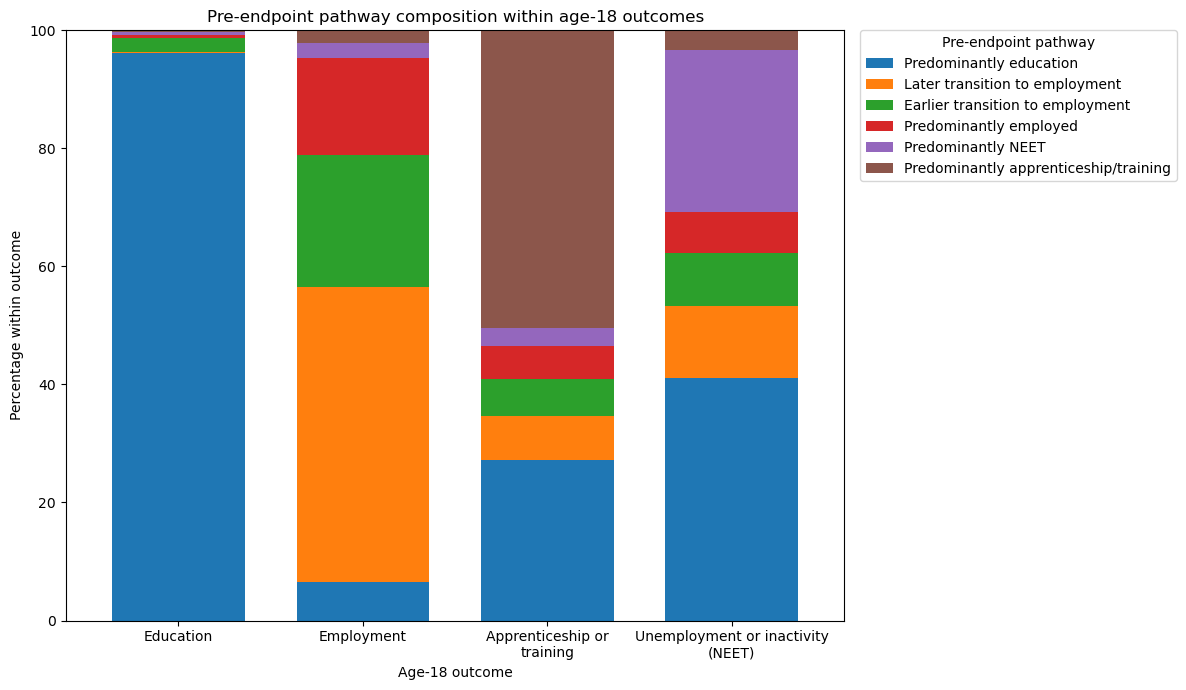

In [26]:
# 4: Plot pre-endpoint pathway composition within age-18 outcomes

import matplotlib.pyplot as plt
outcome_plot_labels = {'Education': 'Education', 'Employment': 'Employment', 'Apprenticeship or training': 'Apprenticeship or\ntraining', 'Unemployment or inactivity (NEET)': 'Unemployment or inactivity\n(NEET)'}
pathway_composition_plot = cluster_outcome_column_percentages.reindex(index=sequence_cluster_order, columns=endpoint_order).T.rename(index=outcome_plot_labels)
figure_path = sequence_output_directory / 'sequence_cluster_composition_by_age18_outcome.png'
fig, ax = plt.subplots(figsize=(12, 7))
pathway_composition_plot.plot(kind='bar', stacked=True, width=0.72, ax=ax)
ax.set_title('Pre-endpoint pathway composition within age-18 outcomes')
ax.set_xlabel('Age-18 outcome')
ax.set_ylabel('Percentage within outcome')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Pre-endpoint pathway', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
fig.savefig(figure_path, dpi=300, bbox_inches='tight')
plt.show()

## Pathway Composition within Age-18 Outcomes

The pathway composition differed substantially across the four age-18 outcomes. Almost all participants in the education outcome had followed a predominantly education pathway. Employment was reached through several pathways, most commonly a later transition to employment, followed by an earlier transition to employment and a predominantly employed history.

Around half of those in the apprenticeship or training outcome had followed a predominantly apprenticeship or training pathway, while the remainder came from several other pathways. The NEET outcome was the most heterogeneous: participants arrived through predominantly education, employment-related and predominantly NEET histories.

The figure therefore shows that some endpoints were closely aligned with a particular pre-endpoint pathway, whereas employment, apprenticeship or training, and especially NEET could follow multiple earlier activity histories.

In [27]:
# 5: Save the sequence-cluster and age-18 outcome results

relationship_table_directory = sequence_output_directory
cluster_outcome_counts_path = relationship_table_directory / 'sequence_cluster_by_age18_outcome_counts.csv'
cluster_outcome_row_percentages_path = relationship_table_directory / 'age18_outcome_composition_within_sequence_clusters.csv'
cluster_outcome_column_percentages_path = relationship_table_directory / 'sequence_cluster_composition_within_age18_outcomes.csv'
endpoint_cluster_summary_path = relationship_table_directory / 'age18_outcome_longitudinal_heterogeneity_summary.csv'
association_summary_path = relationship_table_directory / 'sequence_cluster_age18_outcome_association.csv'
cell_diagnostics_path = relationship_table_directory / 'sequence_cluster_age18_outcome_cell_diagnostics.csv'
cluster_outcome_counts_export = cluster_outcome_counts.rename_axis(index='sequence_cluster', columns='age18_outcome').reset_index()
cluster_outcome_row_percentages_export = cluster_outcome_row_percentages.rename_axis(index='sequence_cluster', columns='age18_outcome').reset_index()
cluster_outcome_column_percentages_export = cluster_outcome_column_percentages.rename_axis(index='sequence_cluster', columns='age18_outcome').reset_index()
association_summary = pd.DataFrame({'participants': [n_participants], 'chi_square': [chi2_statistic], 'degrees_of_freedom': [degrees_of_freedom], 'p_value': [p_value], 'bias_corrected_cramers_v': [cramers_v_corrected], 'minimum_expected_count': [minimum_expected_count], 'cells_with_expected_count_below_5': [expected_counts_below_five]})
cluster_outcome_counts_export.to_csv(cluster_outcome_counts_path, index=False)
cluster_outcome_row_percentages_export.to_csv(cluster_outcome_row_percentages_path, index=False)
cluster_outcome_column_percentages_export.to_csv(cluster_outcome_column_percentages_path, index=False)
endpoint_cluster_summary.to_csv(endpoint_cluster_summary_path, index=False)
association_summary.to_csv(association_summary_path, index=False)
cell_diagnostics.to_csv(cell_diagnostics_path, index=False)
print('Saved relationship tables:')
for path in [cluster_outcome_counts_path, cluster_outcome_row_percentages_path, cluster_outcome_column_percentages_path, endpoint_cluster_summary_path, association_summary_path, cell_diagnostics_path]:
    print(f'- {path.name}')

Saved relationship tables:
- sequence_cluster_by_age18_outcome_counts.csv
- age18_outcome_composition_within_sequence_clusters.csv
- sequence_cluster_composition_within_age18_outcomes.csv
- age18_outcome_longitudinal_heterogeneity_summary.csv
- sequence_cluster_age18_outcome_association.csv
- sequence_cluster_age18_outcome_cell_diagnostics.csv


# Part 5: Final Output Validation

This part confirms the completeness and internal consistency of the participant-level cluster assignments and saved result tables.

In [28]:
# 1: Reload and validate the saved outputs

# Reload exported files to confirm that the stored artefacts reproduce the in-memory results.

required_output_paths = {'Sequence-cluster assignments': sequence_cluster_path, 'Cluster–outcome counts': cluster_outcome_counts_path, 'Outcome composition within clusters': cluster_outcome_row_percentages_path, 'Cluster composition within outcomes': cluster_outcome_column_percentages_path, 'Outcome heterogeneity summary': endpoint_cluster_summary_path, 'Association summary': association_summary_path, 'Cell diagnostics': cell_diagnostics_path, 'Composition figure': figure_path}
for output_name, path in required_output_paths.items():
    if not path.exists():
        raise FileNotFoundError(f'Missing output: {output_name} — {path}')
sequence_clusters_reloaded = pd.read_csv(sequence_cluster_path)
counts_reloaded = pd.read_csv(cluster_outcome_counts_path)
row_percentages_reloaded = pd.read_csv(cluster_outcome_row_percentages_path)
column_percentages_reloaded = pd.read_csv(cluster_outcome_column_percentages_path)
endpoint_summary_reloaded = pd.read_csv(endpoint_cluster_summary_path)
association_reloaded = pd.read_csv(association_summary_path)
cell_diagnostics_reloaded = pd.read_csv(cell_diagnostics_path)
if sequence_clusters_reloaded.shape != (analysis_n, 3):
    raise ValueError('The saved cluster assignment dimensions were incorrect.')
if sequence_clusters_reloaded.isna().any().any():
    raise ValueError('The saved cluster assignments contained missing values.')
if not sequence_clusters_reloaded['NSID'].is_unique:
    raise ValueError('The saved cluster assignments contained duplicate IDs.')
if set(sequence_clusters_reloaded['sequence_cluster_id']) != set(range(1, selected_k + 1)):
    raise ValueError('The saved assignments did not contain the selected number of clusters.')
if counts_reloaded.iloc[:, 1:].to_numpy().sum() != analysis_n:
    raise ValueError('The saved cluster–outcome table did not reproduce the analysis sample.')
if not np.allclose(row_percentages_reloaded.iloc[:, 1:].sum(axis=1), 100.0):
    raise ValueError('The saved row percentages did not sum to 100.')
if not np.allclose(column_percentages_reloaded.iloc[:, 1:].sum(axis=0), 100.0):
    raise ValueError('The saved column percentages did not sum to 100.')
if endpoint_summary_reloaded['participants'].sum() != analysis_n:
    raise ValueError('The saved outcome summary did not reproduce the analysis sample.')
if association_reloaded.loc[0, 'participants'] != analysis_n:
    raise ValueError('The saved association summary had an incorrect sample size.')
if len(cell_diagnostics_reloaded) != selected_k * len(endpoint_order):
    raise ValueError('The saved cell-diagnostic table had an unexpected size.')
verified_cluster_counts = sequence_clusters_reloaded['sequence_cluster'].value_counts().reindex(sequence_cluster_order, fill_value=0)
sequence_outcome_distribution_reloaded = endpoint_summary_reloaded[['age18_outcome', 'participants']].copy().rename(columns={'participants': 'count'})
sequence_outcome_distribution_reloaded['percentage'] = sequence_outcome_distribution_reloaded['count'] / analysis_n * 100
print('Final sequence-analysis validation')
print('----------------------------------')
print('Valid primary outcome participants:', len(age18_outcome))
print('Complete 32-month histories:', analysis_n)
print('Unique 32-month histories:', len(unique_history_table))
print('Selected clusters:', selected_k)
print('Weighted silhouette:', f"{k6_result['best_weighted_silhouette']:.3f}")
print('Minimum cluster mean Jaccard:', f"{k6_cluster_stability['mean_jaccard'].min():.3f}")
print('Median cluster mean Jaccard:', f"{k6_cluster_stability['mean_jaccard'].median():.3f}")
print('Chi-square:', f'{chi2_statistic:,.2f}')
print('Degrees of freedom:', degrees_of_freedom)
print("Bias-corrected Cramér's V:", f'{cramers_v_corrected:.3f}')
print('Minimum expected count:', f'{minimum_expected_count:.2f}')
print()
print('Primary outcome distribution in the sequence-analysis sample:')
display(sequence_outcome_distribution_reloaded)
print()
print('Verified sequence-cluster distribution:')
for cluster_name, count in verified_cluster_counts.items():
    percentage = count / analysis_n * 100
    print(f'- {cluster_name}: {count:,} ({percentage:.2f}%)')
print()
print('Verified output files:')
for output_name, path in required_output_paths.items():
    print(f'- {output_name}: {path.name}')

Final sequence-analysis validation
----------------------------------
Valid primary outcome participants: 9767
Complete 32-month histories: 9724
Unique 32-month histories: 2090
Selected clusters: 6
Weighted silhouette: 0.571
Minimum cluster mean Jaccard: 0.799
Median cluster mean Jaccard: 0.943
Chi-square: 11,654.10
Degrees of freedom: 15
Bias-corrected Cramér's V: 0.632
Minimum expected count: 20.49

Primary outcome distribution in the sequence-analysis sample:


,age18_outcome,count,percentage
0,Education,5124,52.694364
1,Employment,2813,28.928425
2,Apprenticeship or training,523,5.378445
3,Unemployment or inactivity (NEET),1264,12.998766



Verified sequence-cluster distribution:
- Predominantly education: 5,774 (59.38%)
- Later transition to employment: 1,604 (16.50%)
- Earlier transition to employment: 900 (9.26%)
- Predominantly employed: 606 (6.23%)
- Predominantly NEET: 459 (4.72%)
- Predominantly apprenticeship/training: 381 (3.92%)

Verified output files:
- Sequence-cluster assignments: pre_endpoint_activity_sequence_clusters.csv
- Cluster–outcome counts: sequence_cluster_by_age18_outcome_counts.csv
- Outcome composition within clusters: age18_outcome_composition_within_sequence_clusters.csv
- Cluster composition within outcomes: sequence_cluster_composition_within_age18_outcomes.csv
- Outcome heterogeneity summary: age18_outcome_longitudinal_heterogeneity_summary.csv
- Association summary: sequence_cluster_age18_outcome_association.csv
- Cell diagnostics: sequence_cluster_age18_outcome_cell_diagnostics.csv
- Composition figure: sequence_cluster_composition_by_age18_outcome.png


## Final Output Validation

All final outputs were successfully reloaded and validated. The participant-level cluster file contained 9,724 unique participants with complete 32-month histories, no missing values and six sequence clusters. The saved cluster–outcome tables reproduced the analysis sample, and the row and column percentages summed to 100%.

The selected six-cluster solution had a weighted silhouette of 0.571. Across repeated multi-start fits, the minimum cluster mean Jaccard was 0.799 and the median was 0.943. The association between the sequence pathways and the May 2009 outcome was χ²(15) = 11,654.10, p < .001, with a bias-corrected Cramér’s V of 0.632.

The participant assignments, relationship tables, association diagnostics and composition figure were all confirmed as present.

## Interpretation

The primary outcome represents activity in May 2009, while the six sequence clusters summarise activity across the preceding 32 months. Their comparison shows whether participants reaching the same age-18 outcome followed similar or different pre-endpoint activity histories. The results indicate that a single endpoint may be reached through more than one earlier pathway.

This sequence analysis provides supplementary longitudinal context only. The sequence clusters were not used as predictors or as an alternative modelling target in the primary classification analysis.

## Limitations

The monthly activity states represent broad categories and do not distinguish qualification level or type within education. Hamming distance treats each month equally and assigns the same distance to all differences between activity states. The cluster solution may therefore depend on the observation period, distance measure and clustering specification. The sequence analysis excluded 43 participants without complete 32-month histories.